# Bayesian - Gaussian random walk
### Voting Intention aggregation - 2028 Election

## Python set-up

In [1]:
"""Setup and imports."""

import sys

import mgplot as mg
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add pymc tools to path
sys.path.insert(0, "pymc")

from bayes_tools import (
    check_residuals,
    draw_samples,
    grw_model,
    prepare_data_for_analysis,
)
from common import MIDDLE_DATE
from extraction import get_vector_var
from plot_house_effects import plot_house_effects_bar
from plot_posterior_timeseries import plot_posterior_timeseries
from plot_posteriors_bar import plot_posteriors_bar
from polling_data_etl import (
    derived_2pp_variants,
    format_flow_rates,
    load_polling_data,
)
from previous_election import get_election_result, get_last_election

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

SHOW = True
RFOOTER = "marktheballot.blogspot.com"
LFOOTER = "Australia. Polling data sourced from Wikipedia. "

In [2]:
# Set up plotting directory
mg.set_chart_dir("../charts/bayesian-aggregation/")
mg.clear_chart_dir()

## Load Polling Data

Load the most recent voting intention polling data using the ETL module.

In [3]:
# Load voting intention data
df_raw = load_polling_data("voting_intention")
print(f"\nLoaded {len(df_raw)} polls")
print(f"\nColumns: {list(df_raw.columns)}")

Using today's voting_intention data file: ../poll-data/voting_intention_next_2026-09-23.csv

Loaded 223 polls

Columns: ['Date', 'Brand', 'Client', 'Interview mode', 'Sample size', 'Primary vote ALP', 'Primary vote L/NP', 'Primary vote GRN', 'Primary vote ONP', 'Primary vote Others', '2PP vote ALP', '2PP vote L/NP', '2PP vote ONP', 'Primary vote IND', 'parsed_date', 'problematic', 'Others Primary Vote', '2PP synth-2025 ALP', '2PP synth-2025 L/NP', '2PP synth-sa26 ALP', '2PP synth-sa26 ONP']


In [4]:
# Display the raw data
df_raw.head(10)

,Date,Brand,Client,Interview mode,Sample size,Primary vote ALP,Primary vote L/NP,Primary vote GRN,Primary vote ONP,Primary vote Others,2PP vote ALP,2PP vote L/NP,2PP vote ONP,Primary vote IND,parsed_date,problematic,Others Primary Vote,2PP synth-2025 ALP,2PP synth-2025 L/NP,2PP synth-sa26 ALP,2PP synth-sa26 ONP
parsed_date,,,,,,,,,,,,,,,,,,,,,
2026-09-18,15–21 Sept 2026,YouGov,News24,Online,1500,26.0,21.0,14.0,27.0,12.0,52.0,48.0,NaN,NaN,2026-09-18,False,12.0,51.777462,48.222538,51.699,48.301
2026-09-18,15–21 Sept 2026,YouGov,News24,Online,1500,NaN,NaN,NaN,NaN,NaN,55.0,NaN,45.0,NaN,2026-09-18,False,NaN,NaN,NaN,NaN,NaN
2026-09-17,14–20 Sept 2026,Roy Morgan,—N/a,Online,1561,25.0,21.5,15.5,25.5,12.5,53.0,47.0,NaN,NaN,2026-09-17,False,12.5,51.990557,48.009443,52.420,47.580
2026-09-17,14–20 Sept 2026,Roy Morgan,—N/a,Online,1561,NaN,NaN,NaN,NaN,NaN,54.0,NaN,46.0,NaN,2026-09-17,False,NaN,NaN,NaN,NaN,NaN
2026-09-15,14–17 Sept 2026,Newspoll,The Australian,Online,1244,27.0,19.0,13.0,30.0,11.0,NaN,NaN,NaN,NaN,2026-09-15,False,11.0,52.115074,47.884926,50.614,49.386
2026-09-12,10–14 Sept 2026,DemosAU,Capital Brief,Online,1583,28.0,20.0,13.0,26.0,13.0,NaN,NaN,NaN,NaN,2026-09-12,False,13.0,53.186051,46.813949,53.071,46.929
2026-09-10,7–13 Sept 2026,Roy Morgan,—N/a,Online,1583,25.0,21.5,16.0,25.0,12.5,55.0,45.0,NaN,NaN,2026-09-10,False,12.5,52.304007,47.695993,52.844,47.156
2026-09-10,7–13 Sept 2026,Roy Morgan,—N/a,Online,1583,NaN,NaN,NaN,NaN,NaN,54.5,NaN,45.5,NaN,2026-09-10,False,NaN,NaN,NaN,NaN,NaN
2026-09-09,6–12 Sept 2026,Resolve,Sydney Morning Herald/The Age,Telephone & Online,2256,28.0,24.0,11.0,27.0,9.0,NaN,NaN,NaN,NaN,2026-09-09,False,9.0,49.495297,50.504703,50.495,49.505


## Data Preparation

Prepare the data for Bayesian analysis - ensure correct column names and create derived columns.

In [5]:
# Data preparation
df = df_raw.copy()

# Rename parsed_date to Mean Date for compatibility with bayes_tools
if "parsed_date" in df.columns and MIDDLE_DATE not in df.columns:
    df[MIDDLE_DATE] = pd.to_datetime(df["parsed_date"])

# Convert numeric columns
numeric_cols = [
    "2PP vote ALP",
    "2PP vote L/NP",
    "2PP vote ONP",
    "Primary vote ALP",
    "Primary vote L/NP",
    "Primary vote GRN",
    "Primary vote ONP",
    "Primary vote IND",
    "Primary vote OTH",
    "Sample size",
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Create "Others Primary Vote" by summing remaining primary vote columns
main_primary_cols = [
    "Primary vote ALP",
    "Primary vote L/NP",
    "Primary vote GRN",
    "Primary vote ONP",
]
remaining = [
    c for c in df.columns if c not in main_primary_cols and "Primary vote" in c
]
df["Others Primary Vote"] = df[remaining].sum(axis=1, skipna=True)
# Set to NaN where all source columns are NaN
all_nan_rows = df[remaining].isna().all(axis=1)
df.loc[all_nan_rows, "Others Primary Vote"] = np.nan
print(f"Created 'Others Primary Vote' from columns: {remaining}")

print(f"Prepared {len(df)} polls")
df.head()

Created 'Others Primary Vote' from columns: ['Primary vote Others', 'Primary vote IND']
Prepared 223 polls


,Date,Brand,Client,Interview mode,Sample size,Primary vote ALP,Primary vote L/NP,Primary vote GRN,Primary vote ONP,Primary vote Others,2PP vote ALP,2PP vote L/NP,2PP vote ONP,Primary vote IND,parsed_date,problematic,Others Primary Vote,2PP synth-2025 ALP,2PP synth-2025 L/NP,2PP synth-sa26 ALP,2PP synth-sa26 ONP,Mean Date
parsed_date,,,,,,,,,,,,,,,,,,,,,,
2026-09-18,15–21 Sept 2026,YouGov,News24,Online,1500,26.0,21.0,14.0,27.0,12.0,52.0,48.0,NaN,NaN,2026-09-18,False,12.0,51.777462,48.222538,51.699,48.301,2026-09-18
2026-09-18,15–21 Sept 2026,YouGov,News24,Online,1500,NaN,NaN,NaN,NaN,NaN,55.0,NaN,45.0,NaN,2026-09-18,False,NaN,NaN,NaN,NaN,NaN,2026-09-18
2026-09-17,14–20 Sept 2026,Roy Morgan,—N/a,Online,1561,25.0,21.5,15.5,25.5,12.5,53.0,47.0,NaN,NaN,2026-09-17,False,12.5,51.990557,48.009443,52.420,47.580,2026-09-17
2026-09-17,14–20 Sept 2026,Roy Morgan,—N/a,Online,1561,NaN,NaN,NaN,NaN,NaN,54.0,NaN,46.0,NaN,2026-09-17,False,NaN,NaN,NaN,NaN,NaN,2026-09-17
2026-09-15,14–17 Sept 2026,Newspoll,The Australian,Online,1244,27.0,19.0,13.0,30.0,11.0,NaN,NaN,NaN,NaN,2026-09-15,False,11.0,52.115074,47.884926,50.614,49.386,2026-09-15


In [6]:
# Check pollsters (Brand) in the data
print("Pollsters in data:")
print(df["Brand"].value_counts())

Pollsters in data:
Brand
Roy Morgan          69
YouGov              42
RedBridge/Accent    23
Newspoll            18
Resolve             17
DemosAU             13
Essential           12
Fox & Hedgehog      12
Freshwater           7
Spectre Strategy     6
Agenda C Synesis     2
Wolf & Smith         2
Name: count, dtype: int64


In [7]:
# Date range
print(f"Date range: {df[MIDDLE_DATE].min()} to {df[MIDDLE_DATE].max()}")
print(f"Number of days: {(df[MIDDLE_DATE].max() - df[MIDDLE_DATE].min()).days}")

Date range: 2025-05-18 00:00:00 to 2026-09-18 00:00:00
Number of days: 488


## Data Exploration

In [8]:
# Summary statistics
available_cols = [c for c in numeric_cols if c in df.columns]
df[available_cols].describe()

,2PP vote ALP,2PP vote L/NP,2PP vote ONP,Primary vote ALP,Primary vote L/NP,Primary vote GRN,Primary vote ONP,Primary vote IND,Sample size
count,181.000000,132.000000,59.000000,157.000000,157.000000,156.000000,156.000000,41.000000,223.000000
mean,54.010928,46.405470,45.737288,30.589365,23.348590,12.373035,22.110983,11.419570,1733.775785
std,2.178455,3.319259,2.316277,3.185819,3.613068,1.278710,6.543129,2.776048,1056.593640
min,47.368421,41.000000,37.000000,25.000000,16.500000,9.000000,6.000000,5.000000,526.000000
25%,53.000000,44.000000,44.000000,28.000000,21.000000,12.000000,18.000000,9.000000,1243.500000
50%,54.000000,46.000000,46.000000,30.000000,23.000000,12.000000,24.000000,12.000000,1512.000000
75%,56.000000,47.925000,47.000000,33.000000,26.000000,13.000000,27.000000,13.500000,1648.000000
max,59.000000,63.000000,51.000000,38.000000,31.000000,16.000000,32.000000,15.000000,8424.000000


## Prepare Data for Bayesian Analysis

Use `prepare_data_for_analysis` from bayes_tools to create the inputs dictionary for the model.

In [9]:
# Configuration
# House effect constraint: "zero_median" (default) or "zero_sum"
# - zero_median: median of ALL house effects = 0
# - zero_sum: mean of included pollsters = 0 (excludes those with < MIN_POLLS)
MIN_POLLS = 5  # Only used with zero_sum constraint

# 2pp fits to run. "pollster" variants use the pollster-reported 2pp columns;
# every other variant is a derived series (named in polling_data_etl) built
# from primaries via a flow dict. The variant tag is appended to every
# diagnostic chart title so filenames stay unique.
TPP_FITS = [
    {"party": "ALP", "counter": "L/NP", "variant": "pollster"},
    {"party": "ALP", "counter": "ONP",  "variant": "pollster"},
    *[
        {"party": "ALP", "counter": v["counter"], "variant": v["name"]}
        for v in derived_2pp_variants()
    ],
]

# Footer note appended to each variant's time-series chart. Derived series
# get their rates spelled out so the methodology is visible on the chart.
SYNTHETIC_FOOTERS = {
    v["name"]: f" {v['label']} flows: {format_flow_rates(v['flows'])}."
    for v in derived_2pp_variants()
}

# Primary vote parties to fit
PRIMARIES = ["ALP", "L/NP", "GRN", "ONP", "Others"]

# Palettes for plots (matplotlib colormap names)
PALETTES = {
    "ALP": "Reds",
    "L/NP": "Blues",
    "GRN": "Greens",
    "ONP": "YlOrBr",
    "Others": "BuPu",
}

# Key political events: axvline-compatible dicts for finalise_plot
LEADER_CHANGES = [
    {
        "x": pd.Period("2026-02-13", freq="D").ordinal,
        "color": "darkblue",
        "linestyle": "--",
        "linewidth": 0.75,
        "label": "Taylor Lib leader",
    },
    {
        "x": pd.Period("2026-03-11", freq="D").ordinal,
        "color": "forestgreen",
        "linestyle": ":",
        "linewidth": 0.75,
        "label": "Canavan Nat leader",
    },
]


def get_palette(party: str) -> str:
    """Palette name for a given party slug."""
    return PALETTES.get(party, "Blues")


def tpp_columns(variant: str, party: str, counter: str) -> tuple[str, str]:
    """(alp_column, counter_column) for a 2pp variant.

    'pollster' reads the pollster-reported columns; every other variant
    reads the derived ``2PP {variant} ...`` columns built by
    polling_data_etl.add_derived_2pp.
    """
    if variant == "pollster":
        return f"2PP vote {party}", f"2PP vote {counter}"
    return f"2PP {variant} {party}", f"2PP {variant} {counter}"


def get_2pp(
    df: pd.DataFrame, party: str, counter: str, variant: str = "pollster"
) -> pd.DataFrame:
    """Rows where both 2pp columns for this matchup+variant are populated."""
    alp_col, counter_col = tpp_columns(variant, party, counter)
    return df[df[alp_col].notna() & df[counter_col].notna()].copy()


def get_primary(df: pd.DataFrame, party: str) -> pd.DataFrame:
    """Rows where the {party} primary vote is populated.

    For 'Others', uses the composite 'Others Primary Vote' column built by
    polling_data_etl. Relies on the scraper having NaN'd primaries on
    non-classic 2pp rows so primaries are already de-duplicated.
    """
    col = "Others Primary Vote" if party == "Others" else f"Primary vote {party}"
    return df[df[col].notna()].copy()


def primary_column(party: str) -> str:
    """The dataframe column holding {party}'s primary vote share."""
    return "Others Primary Vote" if party == "Others" else f"Primary vote {party}"


def tpp_election_result(party: str, counter: str) -> float | None:
    """Historic 2pp share for {party} in a {party}-vs-{counter} matchup.

    Only the classic ALP-vs-L/NP matchup has a historic 2pp value.
    """
    if {party, counter} != {"ALP", "L/NP"}:
        return None
    election = get_last_election()
    return float(election["Labor2pp"] if party == "ALP" else 100 - election["Labor2pp"])

## Run GRW Model for All Vote Columns

In [10]:
def run_grw_for_column(
    df: pd.DataFrame,
    column: str,
    constraint: str = "zero_median",  # "zero_median" or "zero_sum"
    min_polls: int = 5,  # Only used with zero_sum constraint
    draws: int = 5000,
    tune: int = 1000,
    cores: int = 4,
    target_accept: float = 0.80,
    max_tree_depth: int = 13,  # Increase from default 10 for zero_median
    innovation: float = 0.125,
    likelihood: str = "StudentT",  # "Normal" or "StudentT" for robust estimation
) -> dict:
    """Run GRW model for a single column and return results."""

    print(f"\n{'=' * 60}")
    print(f"Processing: {column}")
    print(f"{'=' * 60}")

    # Filter to rows with valid data for this column
    df_analysis = df[df[column].notna()].copy()

    # Get poll counts by pollster
    poll_counts = df_analysis["Brand"].value_counts()

    print(f"Polls: {len(df_analysis)}")
    print(f"Pollsters: {list(poll_counts.index)}")
    print(f"Constraint: {constraint}")

    # Prepare data - exclusions only needed for zero_sum constraint
    if constraint == "zero_sum":
        he_sum_exclusions = poll_counts[poll_counts < min_polls].index.tolist()
        print(f"Excluded from sum-to-zero (n<{min_polls}): {he_sum_exclusions}")
        inputs = prepare_data_for_analysis(
            df_analysis,
            column=column,
            he_sum_exclusions=he_sum_exclusions,
        )
    else:
        inputs = prepare_data_for_analysis(
            df_analysis,
            column=column,
        )

    # Build and run model
    model = grw_model(
        inputs, innovation=innovation, likelihood=likelihood, constraint=constraint
    )
    idata, glitches = draw_samples(
        model,
        draws=draws,
        tune=tune,
        cores=cores,
        target_accept=target_accept,
        nuts_sampler="numpyro",
        nuts_sampler_kwargs={"max_tree_depth": max_tree_depth},
    )

    if glitches:
        print(f"WARNING: {glitches}")

    print(f"Completed: {column}")

    return {
        "inputs": inputs,
        "model": model,
        "idata": idata,
        "glitches": glitches,
        "constraint": constraint,
        "poll_counts": poll_counts.to_dict(),
        "innovation": innovation,
    }

In [11]:
def grw_plot(
    df: pd.DataFrame,
    column: str,
    color: str,
    title: str,
    election_result: float | None = None,
    footer_note: str = "",
) -> dict:
    """Fit a GRW for `column` in `df` and produce the standard chart set + diagnostics.

    Args:
        df: Polls already filtered to rows where `column` is populated.
        column: The column in `df` holding the vote-share series.
        color: matplotlib palette name.
        title: Human-readable label used in chart titles and series names.
        election_result: Historic election result for this series, or None.
        footer_note: Extra text appended to the time-series chart's lfooter
            (e.g. methodology disclosure for synthetic series).

    Returns:
        The dict from `run_grw_for_column` with two added keys:
        `median` — the per-day posterior-median series (PeriodIndex, daily);
        `loess` — the 90-day LOESS of the raw polls (PeriodIndex over poll
        dates) as returned by the LOESS overlay, or None.
    """
    result = run_grw_for_column(df, column)
    inputs = result["inputs"]
    idata = result["idata"]
    glitches = result["glitches"]
    constraint = result["constraint"]
    poll_counts = result["poll_counts"]

    # Scalar posteriors (sigma_obs, nu, innovation)
    plot_posteriors_bar(
        idata,
        series_name=title,
        rfooter=RFOOTER,
        lfooter=LFOOTER,
        palette=color,
        show=SHOW,
    )

    # House effects
    if constraint == "zero_median":
        rheader = "Median house effect = 0"
    else:
        he_sum_inclusions = inputs["he_sum_inclusions"]
        rheader = f"Sum to zero: {', '.join(he_sum_inclusions)}"
    plot_house_effects_bar(
        idata,
        inputs["back_firm_map"],
        model_name=title,
        poll_counts=poll_counts,
        palette=color,
        rheader=rheader,
        rfooter=RFOOTER,
        lfooter=LFOOTER,
        show=SHOW,
    )

    # Time series
    df_plot = df.copy()
    df_plot.index = pd.PeriodIndex(df_plot[MIDDLE_DATE], freq="D")
    n_polls = len(df_plot)
    assert n_polls == sum(poll_counts.values())

    vi_samples = get_vector_var("voting_intention", idata)
    vi_samples = vi_samples - inputs["centre_offset"]
    date_index = pd.period_range(inputs["day_zero"], periods=len(vi_samples), freq="D")
    vi_samples.index = date_index

    # Shared kwargs for the two time-series charts (with/without LOESS overlay).
    ts_kwargs = dict(
        data=vi_samples,
        poll_data=df_plot,
        poll_column=column,
        election_result=election_result,
        palette=color,
        ylabel="Vote share (%)",
        axvline=LEADER_CHANGES,
        legend={"loc": "best", "fontsize": "xx-small", "ncol": 2},
        lheader=glitches if glitches else "",
        rheader=f"SD of daily innovation = {result['innovation']}",
        rfooter=RFOOTER,
        lfooter=f"{LFOOTER}n={n_polls} polls.{footer_note}",
        show=SHOW,
    )

    # Standard time-series chart (GRW only).
    plot_posterior_timeseries(title=f"Voting Intention: {title}", **ts_kwargs)

    # Additional time-series chart: same GRW fit plus a 120-day LOESS overlay.
    # With loess=True the call returns the LOESS series it drew, so we reuse
    # it for the combined primary-vote LOESS chart (no re-computation). Both
    # the Bayesian median and the LOESS are annotated at their end points.
    loess_series = plot_posterior_timeseries(
        title=f"Voting Intention: {title} — Bayesian + LOESS",
        loess=True,
        loess_day_span=120,
        **ts_kwargs,
    )

    # Residual diagnostics
    check_residuals(inputs, idata, verbose=True, show=SHOW, series_label=title)

    # Capture per-day posterior median for downstream combined charts
    result["median"] = vi_samples.quantile(q=0.5, axis=1)
    result["median"].name = title

    # Capture the 90-day LOESS used in the overlay for the combined chart
    result["loess"] = loess_series
    if loess_series is not None:
        result["loess"].name = title

    return result

In [12]:
# Solid party colours for the combined primary-medians chart (lines + dots)
PARTY_COLORS = {
    "ALP": "#dd0000",
    "L/NP": "#0000dd",
    "GRN": "#009900",
    "ONP": "darkorange",
    "Others": "gray",
}


def _normalise_to_100(series: dict[str, pd.Series]) -> pd.DataFrame:
    """Rescale a set of posterior-median series so they sum to 100 at each date.

    Why this is needed: every party's primary is fit as its own independent
    Gaussian random walk, each over only the polls that report that party,
    with its own house-effect centring. Nothing in the model ties the series
    together, so their posterior medians do not sum to exactly 100. A practical
    contributor is partial polls: a pollster may report only some primaries, so
    that poll informs the series it covers but is not reconciled against the
    others. (Even with fully-complete polls the independent fits would not sum
    to exactly 100 — this is not just rounding.) We therefore present the raw
    per-party estimates from their own fits, then rescale here purely for the
    summed/derived views so the components add to 100.

    Aligns the series on their common (intersection) date range, then divides
    each by the row total. Shared by the primary-medians and bloc charts.
    """
    df = pd.DataFrame(series).dropna()
    return df.div(df.sum(axis=1), axis=0) * 100.0


def plot_primary_medians_combined(
    medians: dict[str, pd.Series],
    raw_polls: dict[str, pd.DataFrame],
) -> None:
    """Draw a 9x9 chart with posterior-median lines and raw-poll dots for
    every primary party, colour-coded by party."""
    _fig, ax = plt.subplots(figsize=(9.0, 9.0))

    # Scatter raw polls first so median lines overlay them
    for party in PRIMARIES:
        if party not in medians:
            continue
        color = PARTY_COLORS.get(party, "black")
        col = primary_column(party)
        poll_df = raw_polls.get(party)
        if poll_df is None or poll_df.empty:
            continue
        vals = poll_df[col].dropna()
        if vals.empty:
            continue
        x = [p.ordinal for p in vals.index]
        ax.scatter(x, vals.to_numpy(), color=color, s=18, alpha=0.4, zorder=3)

    # mg.line_plot for the medians so the x-axis gets date formatting.
    # Normalise the median lines to sum to 100 each day; raw-poll dots stay
    # as reported.
    medians_df = _normalise_to_100(
        {p: medians[p] for p in PRIMARIES if p in medians}
    )
    colors = [PARTY_COLORS.get(p, "black") for p in medians_df.columns]
    mg.line_plot(
        medians_df,
        ax=ax,
        color=colors,
        style="solid",
        width=2,
        annotate=True,
    )

    mg.finalise_plot(
        ax,
        title="Primary Vote — Posterior Medians",
        xlabel=None,
        ylabel="Vote share (%)",
        legend={"loc": "best", "fontsize": "small"},
        figsize=(9.0, 9.0),
        rfooter=RFOOTER,
        lfooter=f"{LFOOTER}Median lines normalised to sum to 100.",
        show=SHOW,
    )

In [13]:
def plot_primary_loess_combined(
    loess: dict[str, pd.Series],
    raw_polls: dict[str, pd.DataFrame],
    day_span: int = 90,
) -> None:
    """Draw a 9x9 chart with 90-day LOESS lines and raw-poll dots for every
    primary party, normalised so the LOESS lines sum to 100 at each date.

    The LOESS series are the ones already computed for the per-party
    time-series overlays (returned by plot_posterior_timeseries(loess=True));
    here we only reindex each to a daily grid so the independently-dated
    series share an x-axis, then normalise. Mirrors
    plot_primary_medians_combined but with LOESS in place of the GRW median.
    """
    _fig, ax = plt.subplots(figsize=(9.0, 9.0))

    # Scatter raw polls first so the LOESS lines overlay them
    for party in PRIMARIES:
        if party not in loess or loess[party] is None:
            continue
        color = PARTY_COLORS.get(party, "black")
        col = primary_column(party)
        poll_df = raw_polls.get(party)
        if poll_df is None or poll_df.empty:
            continue
        vals = poll_df[col].dropna()
        if vals.empty:
            continue
        x = [p.ordinal for p in vals.index]
        ax.scatter(x, vals.to_numpy(), color=color, s=18, alpha=0.4, zorder=3)

    # Reindex each LOESS series onto a daily grid (linearly interpolated)
    # so the differently-dated series align, then normalise to sum to 100.
    daily: dict[str, pd.Series] = {}
    for party in PRIMARIES:
        s = loess.get(party)
        if s is None or s.empty:
            continue
        grid = pd.period_range(s.index.min(), s.index.max(), freq="D")
        daily[party] = s.reindex(grid).interpolate()

    loess_df = _normalise_to_100(daily)
    colors = [PARTY_COLORS.get(p, "black") for p in loess_df.columns]
    mg.line_plot(
        loess_df,
        ax=ax,
        color=colors,
        style="solid",
        width=2,
        annotate=True,
    )

    mg.finalise_plot(
        ax,
        title=f"Primary Vote — {day_span}-day LOESS",
        xlabel=None,
        ylabel="Vote share (%)",
        legend={"loc": "best", "fontsize": "small"},
        figsize=(9.0, 9.0),
        rfooter=RFOOTER,
        lfooter=f"{LFOOTER}{day_span}-day LOESS lines normalised to sum to 100.",
        show=SHOW,
    )

In [14]:
def plot_2pp_medians_combined(medians: dict[str, pd.Series]) -> None:
    """Draw a 9x9 chart overlaying every fitted 2pp variant's posterior
    median — no dots, lines only. Used for side-by-side comparison of
    pollster vs synthetic vs shadow-2pp estimates."""
    if not medians:
        return
    _fig, ax = plt.subplots(figsize=(9.0, 9.0))
    medians_df = pd.DataFrame(medians)
    # Colour by counter-party (parsed from "<party> vs <counter> (<variant>)")
    colors = [
        PARTY_COLORS.get(c.split(" vs ")[1].split(" (")[0], "black")
        for c in medians_df.columns
    ]
    mg.line_plot(
        medians_df,
        ax=ax,
        color=colors,
        style=["-", "--", ":", "-."] * int(len(medians_df.columns)/4 + 1),
        width=2,
        annotate=True,
    )
    mg.finalise_plot(
        ax,
        title="ALP 2pp — Posterior Medians (all variants)",
        xlabel=None,
        ylabel="ALP 2pp share (%)",
        legend={"loc": "best", "fontsize": "small"},
        figsize=(9.0, 9.0),
        rfooter=RFOOTER,
        lfooter=f"{LFOOTER}Flow sources: {', '.join(v['label'] for v in derived_2pp_variants())}.",
        show=SHOW,
    )


In [15]:
# Derived voting blocs from the primary-vote posterior medians.
# Each bloc is a weighted element-wise sum of the per-party median series
# (aligned on their common date range), then normalised so the two blocs
# sum to 100 each day (via _normalise_to_100, defined above).
# Drawn lines-only at the standard chart size, footnoted, with a 50% line.
#   Major = ALP + L/NP;  Other = the remaining primaries.
#   Left  = ALP + GRN + half of Others;  Right = L/NP + ONP + half of Others.

# Dashed reference line at the 50% level for the bloc charts.
HALF_LINE = {"y": 50, "color": "black", "linewidth": 0.75, "linestyle": "--"}


def _combine_medians(
    medians: dict[str, pd.Series], weights: dict[str, float]
) -> pd.Series:
    """Weighted element-wise sum of party posterior-median series.

    `weights` maps party slug -> weight. Series are aligned on their common
    (intersection) date range so the sum is well defined even though each
    party's GRW is fit over a different span of polls.
    """
    parts = [medians[p] * w for p, w in weights.items() if p in medians]
    return pd.concat(parts, axis=1).dropna().sum(axis=1)


def plot_blocs_combined(medians: dict[str, pd.Series]) -> None:
    """Emit the Major-vs-Other and Left-vs-Right bloc charts from the
    primary-vote posterior medians, at the standard chart size."""

    # --- Major (ALP+L/NP) vs Other ---
    major = _combine_medians(medians, {"ALP": 1.0, "L/NP": 1.0})
    other = _combine_medians(medians, {"GRN": 1.0, "ONP": 1.0, "Others": 1.0})
    mvo = _normalise_to_100({"Major (ALP + L/NP)": major, "Other": other})
    _fig, ax = plt.subplots()
    mg.line_plot(
        mvo,
        ax=ax,
        color=["#800080", "gray"],
        style="solid",
        width=2,
        annotate=True,
    )
    mg.finalise_plot(
        ax,
        title="Major vs Other — Posterior Medians",
        xlabel=None,
        ylabel="Primary vote share (%)",
        legend={"loc": "best", "fontsize": "small"},
        axhline=HALF_LINE,
        rfooter=RFOOTER,
        lfooter="Major = ALP + L/NP primaries; Other = GRN + ONP + remaining primaries. Normalised to 100.",
        show=SHOW,
    )

    # --- Left vs Right (Others split 50/50) ---
    left = _combine_medians(medians, {"ALP": 1.0, "GRN": 1.0, "Others": 0.5})
    right = _combine_medians(medians, {"L/NP": 1.0, "ONP": 1.0, "Others": 0.5})
    lr = _normalise_to_100(
        {
            "Left (ALP + GRN + ½ Other)": left,
            "Right (L/NP + ONP + ½ Other)": right,
        }
    )
    _fig, ax = plt.subplots()
    mg.line_plot(
        lr,
        ax=ax,
        color=["#dd0000", "#0000dd"],
        style="solid",
        width=2,
        annotate=True,
    )
    mg.finalise_plot(
        ax,
        title="Left vs Right — Posterior Medians",
        xlabel=None,
        ylabel="Primary vote share (%)",
        legend={"loc": "best", "fontsize": "small"},
        axhline=HALF_LINE,
        rfooter=RFOOTER,
        lfooter="Left = ALP + GRN + ½·Others; Right = L/NP + ONP + ½·Others (Others split 50/50). Normalised to 100.",
        show=SHOW,
    )

/Users/bryanpalmer/Election-2028/notebooks/pymc/bayes_tools.py:585: FutureWarning: `nuts_sampler_kwargs` is deprecated. Pass NUTS keyword arguments via the `nuts={...}` argument to `pm.sample`.
  idata = pm.sample(
NUTS[numpyro]: [voting_intention, raw_he, sigma_obs, nu]



Processing: Primary vote ALP
Polls: 157
Pollsters: ['Roy Morgan', 'YouGov', 'Newspoll', 'Resolve', 'RedBridge/Accent', 'DemosAU', 'Essential', 'Freshwater', 'Spectre Strategy', 'Fox & Hedgehog', 'Wolf & Smith', 'Agenda C Synesis']
Constraint: zero_median
sigma_obs HalfNormal prior: {'sigma': 5}
nu Gamma prior: {'alpha': 2, 'beta': 0.1}


  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

Maximum R-hat: 1.0000
Minimum ESS: 2100
Maximum MCSE/sd ratio: 0.022
Divergent transitions: 0/20000 (0.0000%)
Tree depth at max (12): 0.08% (comparing to observed max)
Minimum BFMI: 0.95
Completed: Primary vote ALP


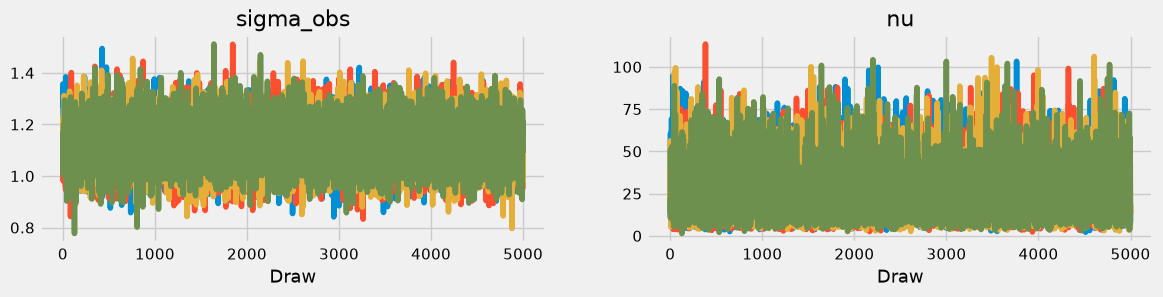

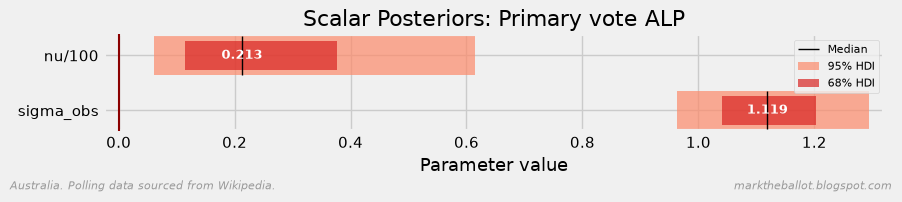

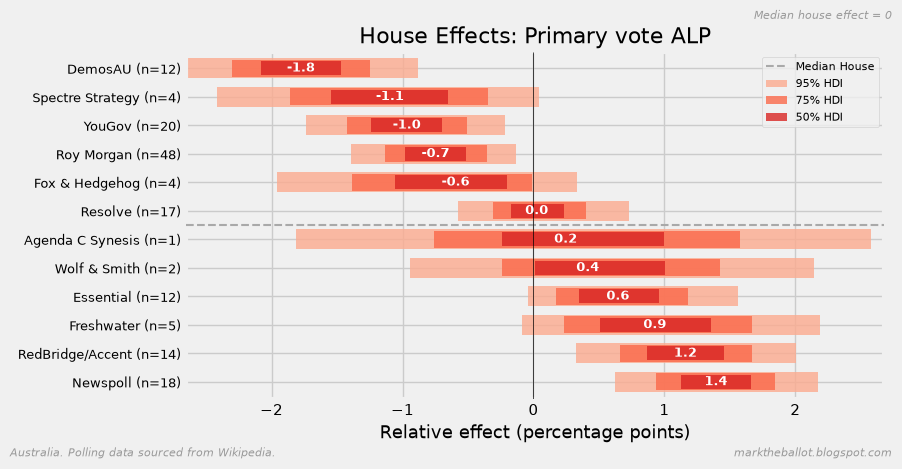

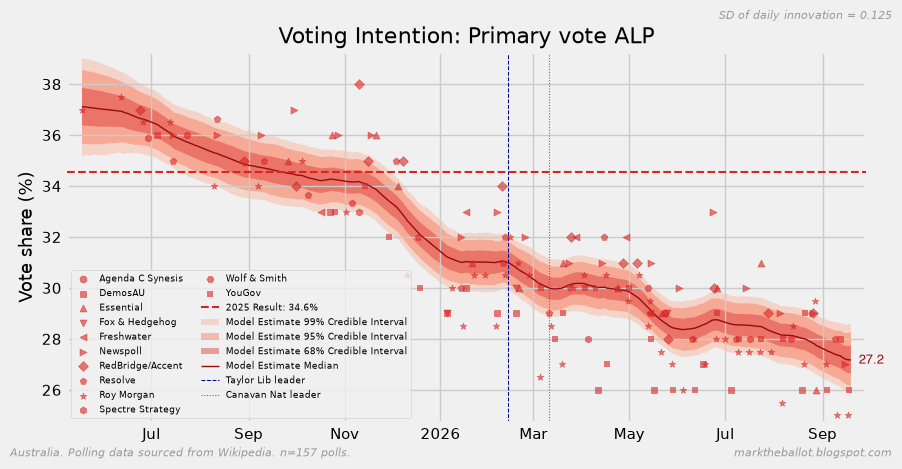

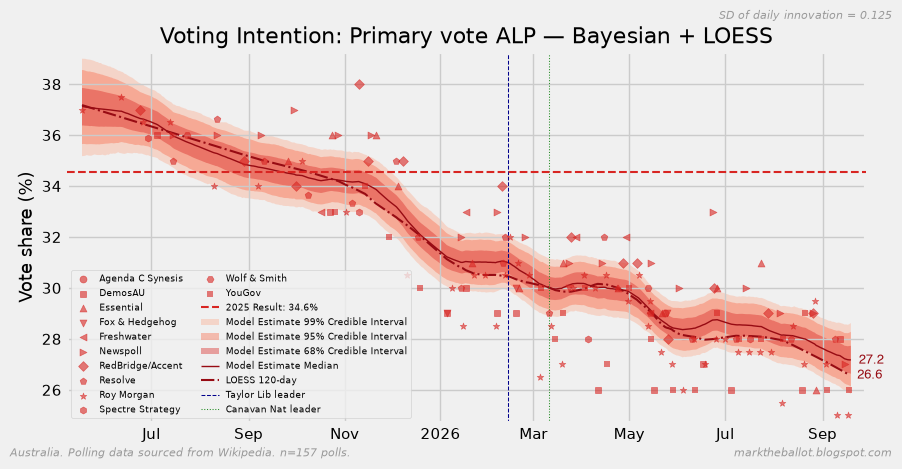

/Users/bryanpalmer/Election-2028/notebooks/pymc/bayes_tools.py:585: FutureWarning: `nuts_sampler_kwargs` is deprecated. Pass NUTS keyword arguments via the `nuts={...}` argument to `pm.sample`.
  idata = pm.sample(
NUTS[numpyro]: [voting_intention, raw_he, sigma_obs, nu]



=== Residual Diagnostics by Pollster ===
Model sigma_obs: 1.12
Minimum polls required: 5

Roy Morgan (n=48)
  Outside ±3σ: 0/48 (0.0%)
  Heteroskedasticity p-value: 0.657 (homoskedastic)
  Recent outliers: 0@3σ, 1@2σ (of 5)
  Mean shift: +0.00 (t-test p=0.993)

RedBridge/Accent (n=14)
  Outside ±3σ: 0/14 (0.0%)
  Heteroskedasticity p-value: 0.283 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.44 (t-test p=0.524)

DemosAU (n=12)
  Outside ±3σ: 0/12 (0.0%)
  Heteroskedasticity p-value: 0.400 (homoskedastic)
  Recent outliers: 0@3σ, 1@2σ (of 5)
  Mean shift: -0.62 (t-test p=0.407)

Newspoll (n=18)
  Outside ±3σ: 0/18 (0.0%)
  Heteroskedasticity p-value: 0.485 (homoskedastic)
  Recent outliers: 0@3σ, 1@2σ (of 5)
  Mean shift: +0.01 (t-test p=0.988)

Resolve (n=17)
  Outside ±3σ: 0/17 (0.0%)
  Heteroskedasticity p-value: 0.443 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +0.15 (t-test p=0.758)

Essential (n=12)
  Outside ±3σ: 0/12 (0.0%)
  Heter

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

Maximum R-hat: 1.0000
Minimum ESS: 3800
Maximum MCSE/sd ratio: 0.016
Divergent transitions: 0/20000 (0.0000%)
Tree depth at max (11): 1.10% (comparing to observed max)
Minimum BFMI: 0.98
Completed: Primary vote L/NP


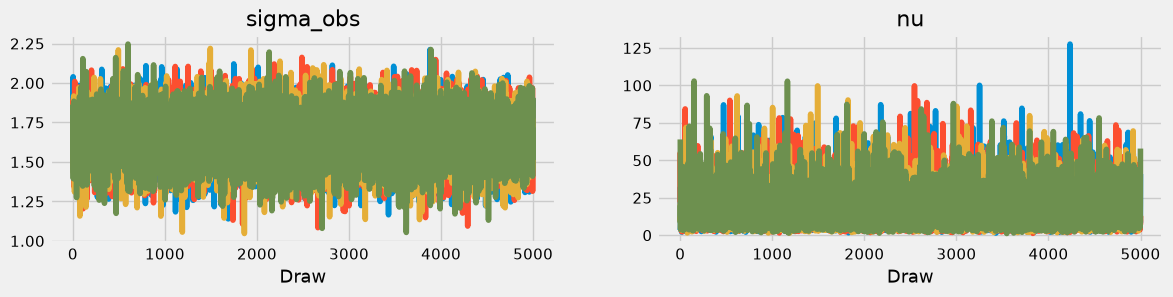

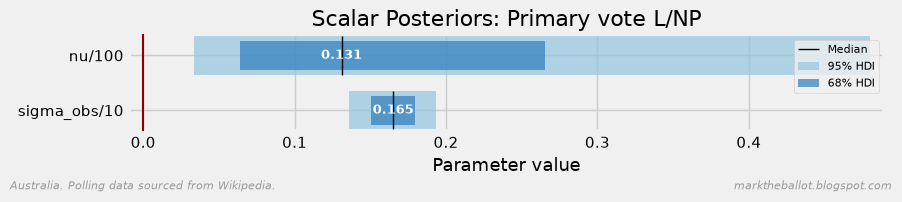

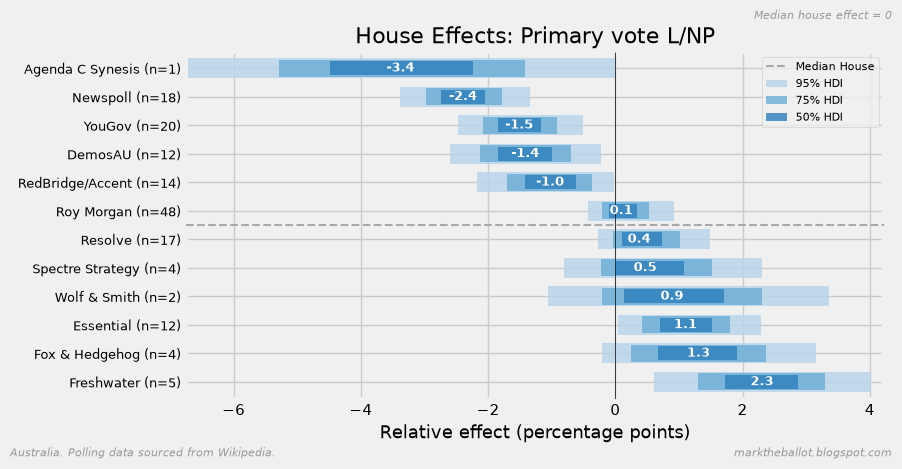

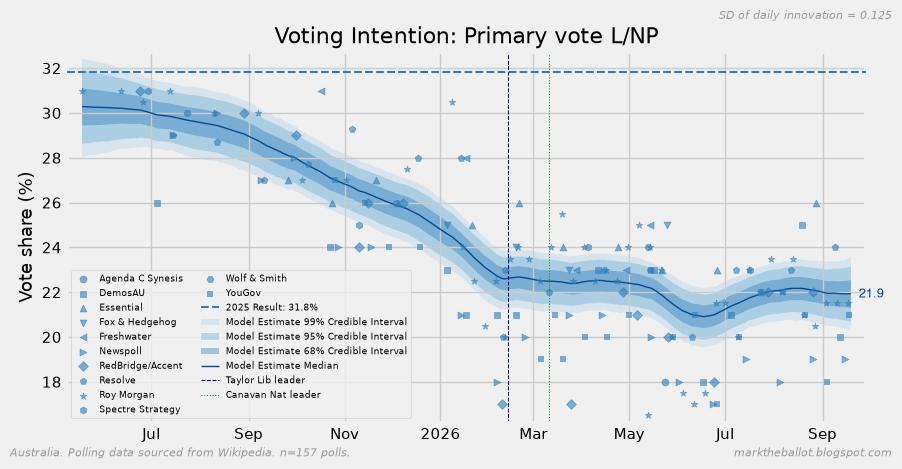

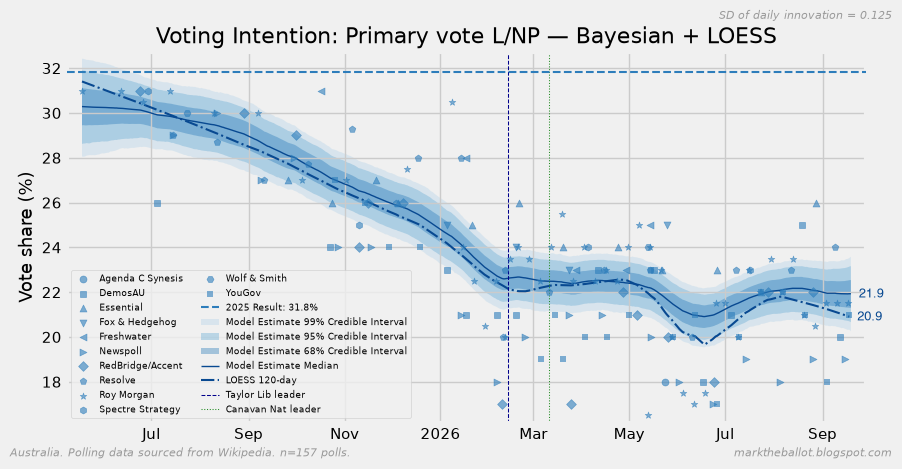


=== Residual Diagnostics by Pollster ===
Model sigma_obs: 1.65
Minimum polls required: 5

Roy Morgan (n=48) ⚠️ SUSPECT
  Outside ±3σ: 2/48 (4.2%)
  Heteroskedasticity p-value: 0.641 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -1.08 (t-test p=0.054)

RedBridge/Accent (n=14)
  Outside ±3σ: 0/14 (0.0%)
  Heteroskedasticity p-value: 0.807 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.91 (t-test p=0.459)

DemosAU (n=12) ⚠️ SUSPECT
  Outside ±3σ: 0/12 (0.0%)
  Heteroskedasticity p-value: 0.544 (homoskedastic)
  Recent outliers: 0@3σ, 1@2σ (of 5)
  Mean shift: +2.32 (t-test p=0.041)

Newspoll (n=18)
  Outside ±3σ: 0/18 (0.0%)
  Heteroskedasticity p-value: 0.086 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.82 (t-test p=0.224)

Resolve (n=17)
  Outside ±3σ: 0/17 (0.0%)
  Heteroskedasticity p-value: 0.567 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.53 (t-test p=0.539)

Essential (n=12)
  Outside ±3

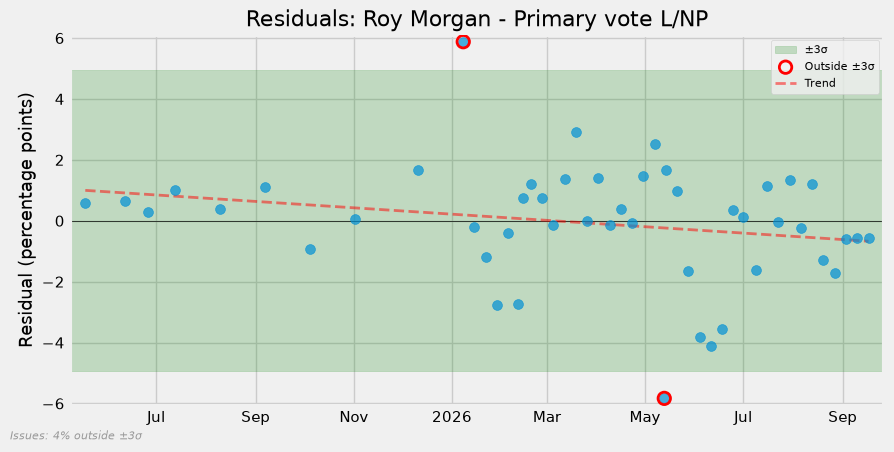

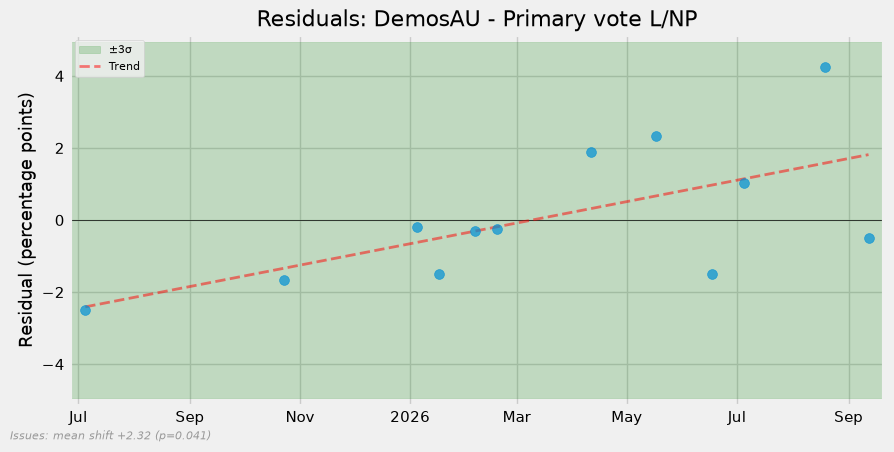

/Users/bryanpalmer/Election-2028/notebooks/pymc/bayes_tools.py:585: FutureWarning: `nuts_sampler_kwargs` is deprecated. Pass NUTS keyword arguments via the `nuts={...}` argument to `pm.sample`.
  idata = pm.sample(
NUTS[numpyro]: [voting_intention, raw_he, sigma_obs, nu]



Processing: Primary vote GRN
Polls: 156
Pollsters: ['Roy Morgan', 'YouGov', 'Newspoll', 'Resolve', 'RedBridge/Accent', 'DemosAU', 'Essential', 'Freshwater', 'Spectre Strategy', 'Fox & Hedgehog', 'Agenda C Synesis', 'Wolf & Smith']
Constraint: zero_median
sigma_obs HalfNormal prior: {'sigma': 5}
nu Gamma prior: {'alpha': 2, 'beta': 0.1}


  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

Maximum R-hat: 1.0000
Minimum ESS: 2600
Maximum MCSE/sd ratio: 0.020
Divergent transitions: 0/20000 (0.0000%)
Tree depth at max (12): 0.19% (comparing to observed max)
Minimum BFMI: 0.97
Completed: Primary vote GRN


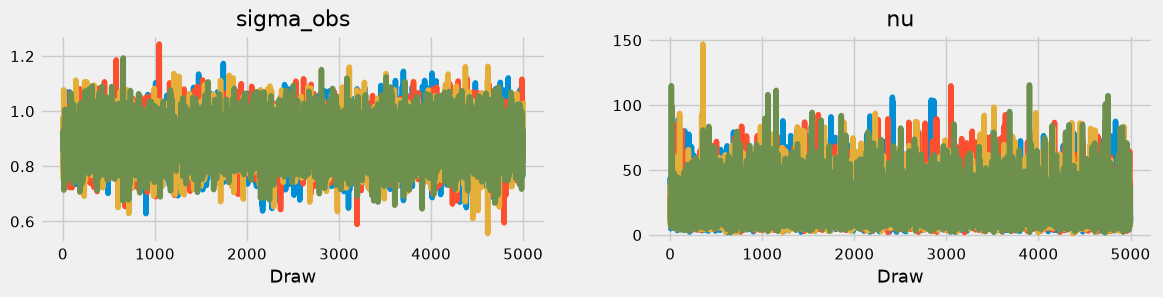

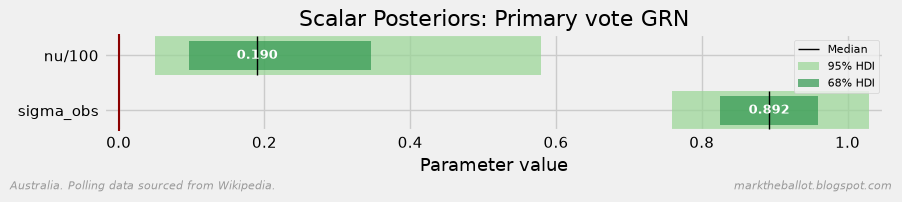

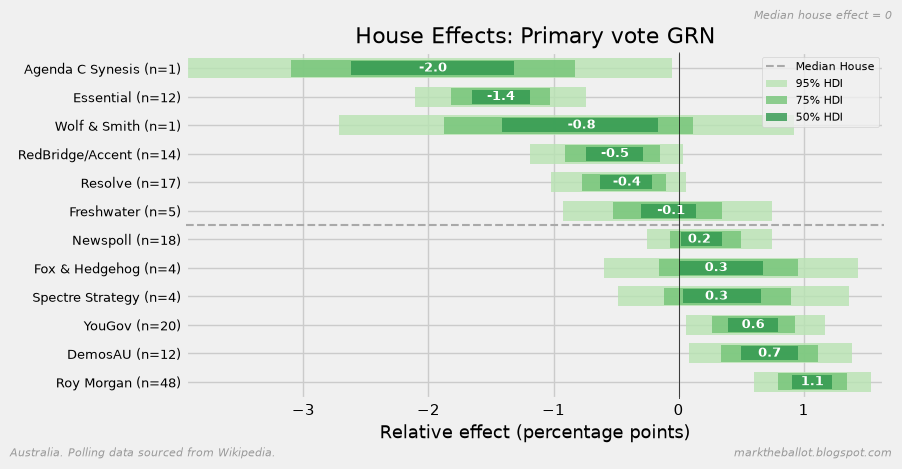

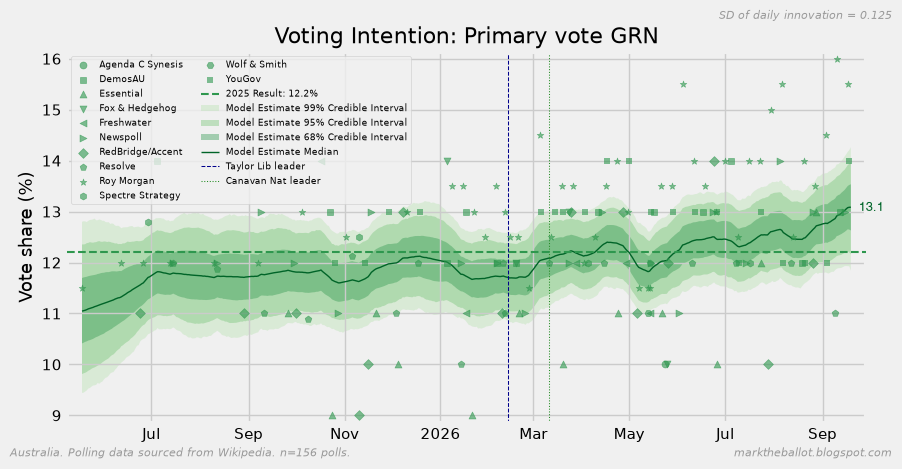

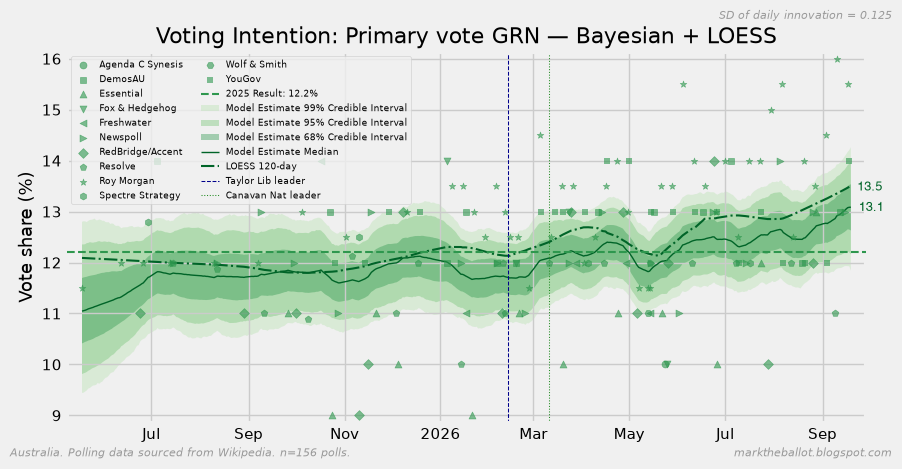


=== Residual Diagnostics by Pollster ===
Model sigma_obs: 0.89
Minimum polls required: 5

Roy Morgan (n=48) ⚠️ SUSPECT
  Outside ±3σ: 0/48 (0.0%)
  Heteroskedasticity p-value: 0.033 (variance increasing)
  Recent outliers: 0@3σ, 1@2σ (of 5)
  Mean shift: +0.44 (t-test p=0.086)

RedBridge/Accent (n=14) ⚠️ SUSPECT
  Outside ±3σ: 0/14 (0.0%)
  Heteroskedasticity p-value: 0.389 (homoskedastic)
  Recent outliers: 0@3σ, 2@2σ (of 5)
  Mean shift: +0.71 (t-test p=0.300)

DemosAU (n=12)
  Outside ±3σ: 0/12 (0.0%)
  Heteroskedasticity p-value: 0.303 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.30 (t-test p=0.526)

Resolve (n=17)
  Outside ±3σ: 0/17 (0.0%)
  Heteroskedasticity p-value: 0.633 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +0.04 (t-test p=0.910)

Newspoll (n=18)
  Outside ±3σ: 0/18 (0.0%)
  Heteroskedasticity p-value: 0.725 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.12 (t-test p=0.712)

Essential (n=12)
  Outs

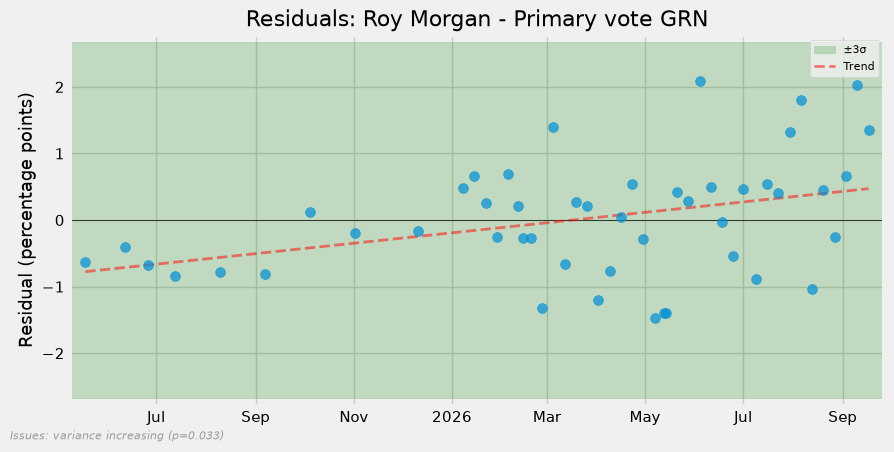

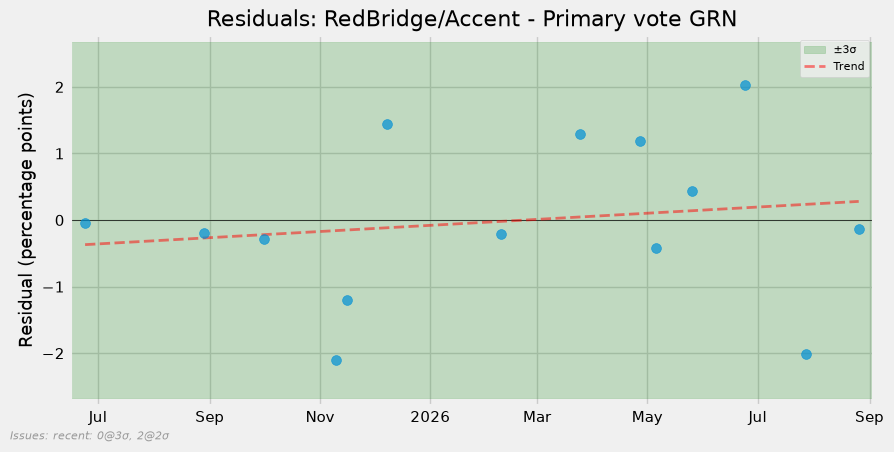

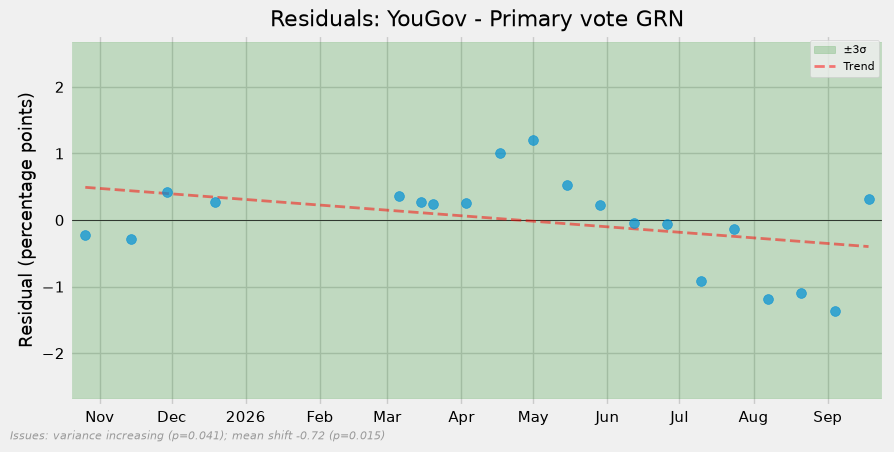

/Users/bryanpalmer/Election-2028/notebooks/pymc/bayes_tools.py:585: FutureWarning: `nuts_sampler_kwargs` is deprecated. Pass NUTS keyword arguments via the `nuts={...}` argument to `pm.sample`.
  idata = pm.sample(
NUTS[numpyro]: [voting_intention, raw_he, sigma_obs, nu]



Processing: Primary vote ONP
Polls: 156
Pollsters: ['Roy Morgan', 'YouGov', 'Newspoll', 'Resolve', 'RedBridge/Accent', 'DemosAU', 'Essential', 'Freshwater', 'Spectre Strategy', 'Fox & Hedgehog', 'Agenda C Synesis', 'Wolf & Smith']
Constraint: zero_median
sigma_obs HalfNormal prior: {'sigma': 5}
nu Gamma prior: {'alpha': 2, 'beta': 0.1}


  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

Maximum R-hat: 1.0000
Minimum ESS: 3100
Maximum MCSE/sd ratio: 0.018
Divergent transitions: 0/20000 (0.0000%)
Tree depth at max (12): 0.01% (comparing to observed max)
Minimum BFMI: 0.98
Completed: Primary vote ONP


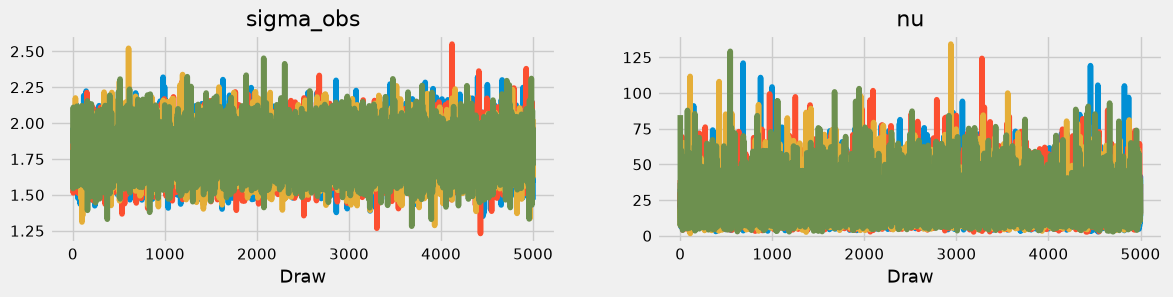

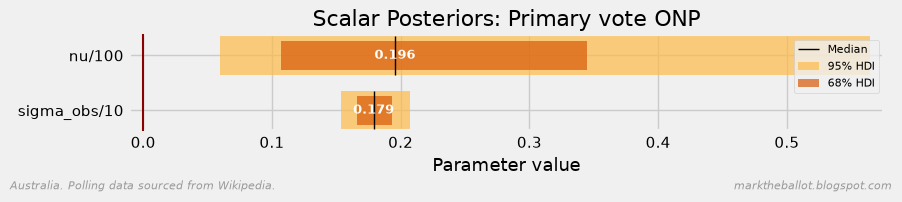

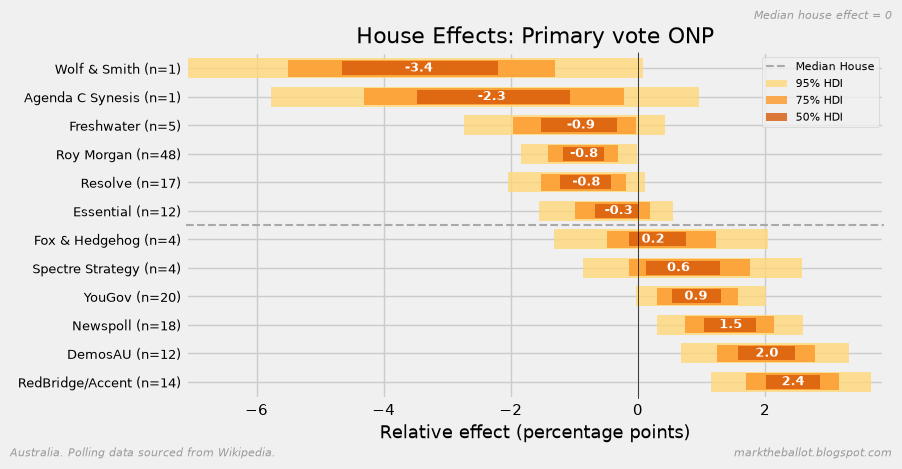

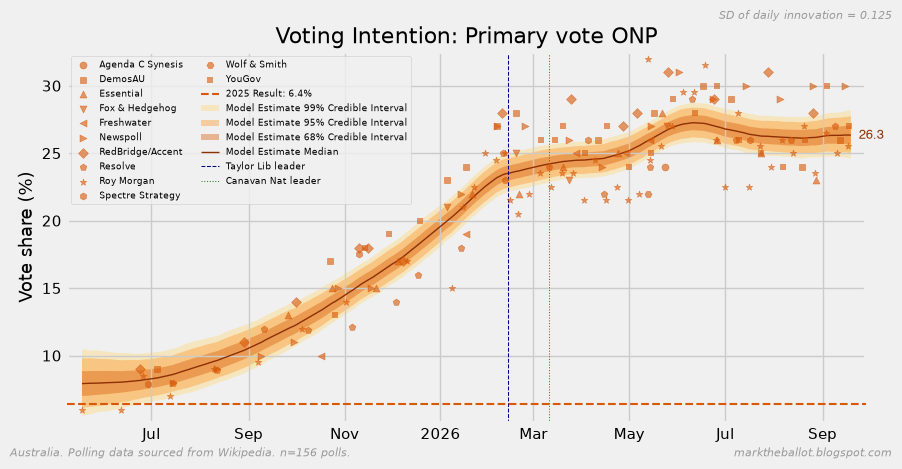

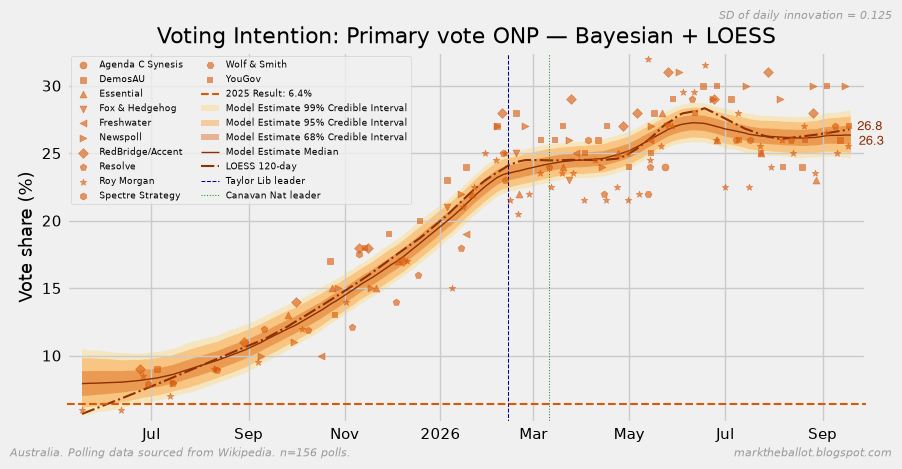


=== Residual Diagnostics by Pollster ===
Model sigma_obs: 1.79
Minimum polls required: 5

Roy Morgan (n=48)
  Outside ±3σ: 1/48 (2.1%)
  Heteroskedasticity p-value: 0.322 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +0.26 (t-test p=0.685)

RedBridge/Accent (n=14)
  Outside ±3σ: 0/14 (0.0%)
  Heteroskedasticity p-value: 0.830 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +1.31 (t-test p=0.129)

DemosAU (n=12)
  Outside ±3σ: 0/12 (0.0%)
  Heteroskedasticity p-value: 0.222 (homoskedastic)
  Recent outliers: 0@3σ, 1@2σ (of 5)
  Mean shift: -1.99 (t-test p=0.059)

Resolve (n=17)
  Outside ±3σ: 0/17 (0.0%)
  Heteroskedasticity p-value: 0.649 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +1.30 (t-test p=0.080)

Newspoll (n=18) ⚠️ SUSPECT
  Outside ±3σ: 0/18 (0.0%)
  Heteroskedasticity p-value: 0.512 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +1.87 (t-test p=0.035)

Essential (n=12)
  Outside ±3σ: 0/12 (0.

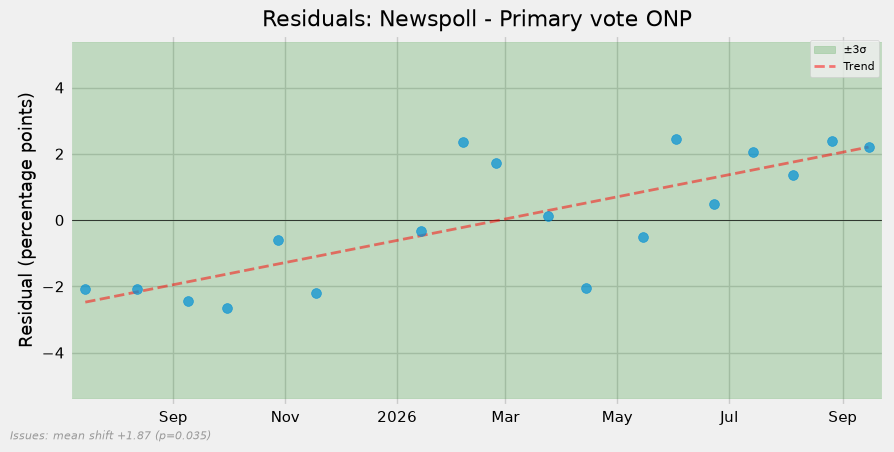

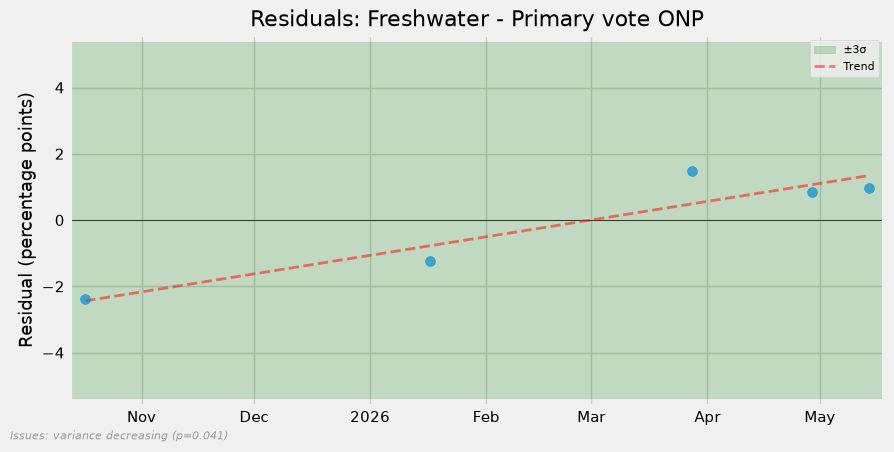

/Users/bryanpalmer/Election-2028/notebooks/pymc/bayes_tools.py:585: FutureWarning: `nuts_sampler_kwargs` is deprecated. Pass NUTS keyword arguments via the `nuts={...}` argument to `pm.sample`.
  idata = pm.sample(
NUTS[numpyro]: [voting_intention, raw_he, sigma_obs, nu]



Processing: Others Primary Vote
Polls: 156
Pollsters: ['Roy Morgan', 'YouGov', 'Newspoll', 'Resolve', 'RedBridge/Accent', 'DemosAU', 'Essential', 'Freshwater', 'Spectre Strategy', 'Fox & Hedgehog', 'Agenda C Synesis', 'Wolf & Smith']
Constraint: zero_median
sigma_obs HalfNormal prior: {'sigma': 5}
nu Gamma prior: {'alpha': 2, 'beta': 0.1}


  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

Maximum R-hat: 1.0000
Minimum ESS: 5100
Maximum MCSE/sd ratio: 0.014
Divergent transitions: 0/20000 (0.0000%)
Tree depth at max (12): 0.01% (comparing to observed max)
Minimum BFMI: 0.97
Completed: Others Primary Vote


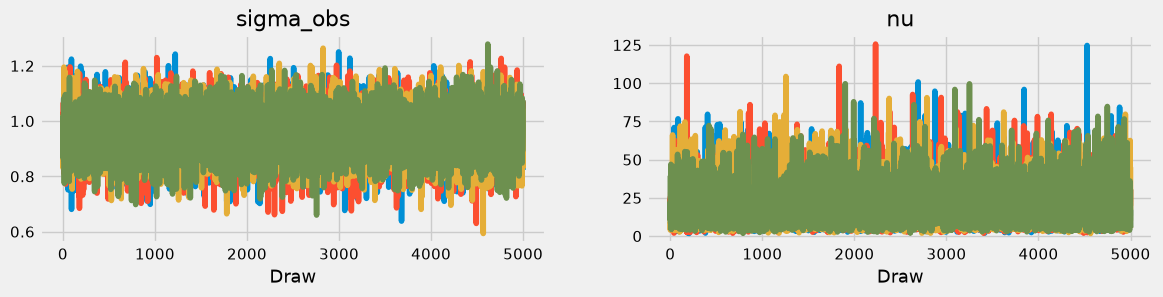

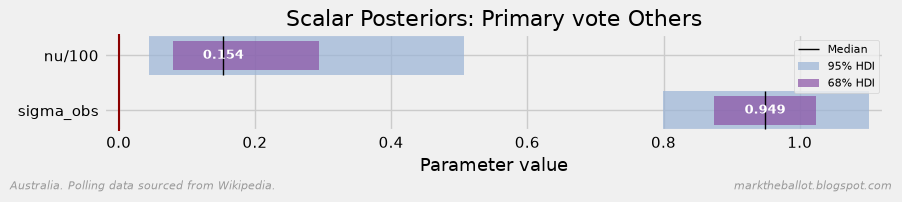

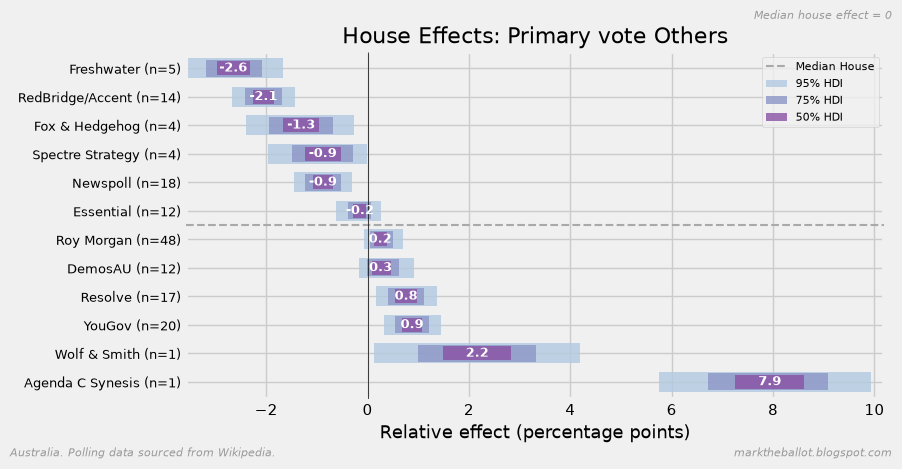

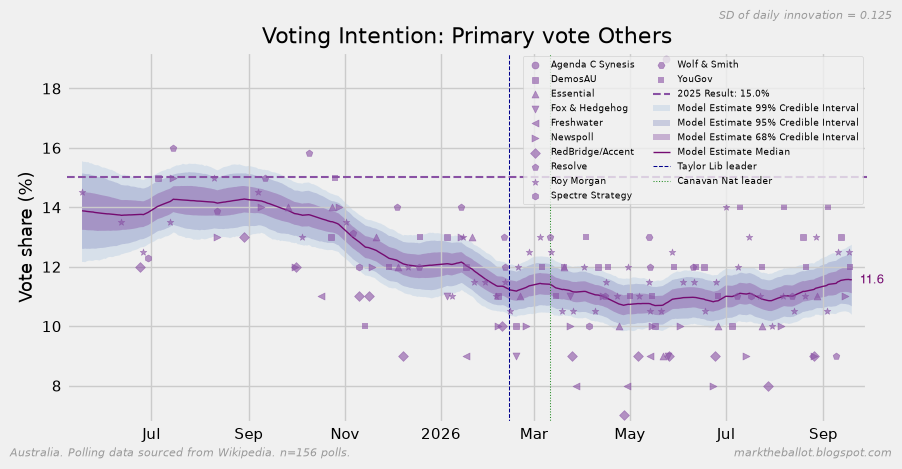

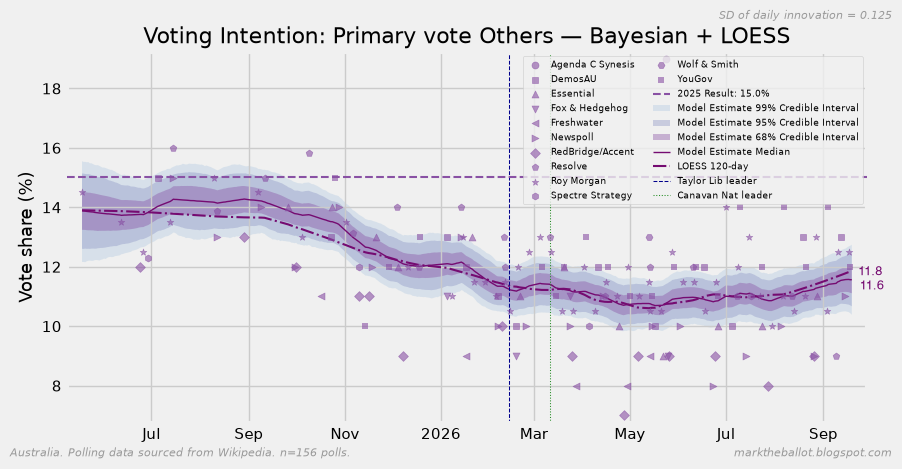


=== Residual Diagnostics by Pollster ===
Model sigma_obs: 0.95
Minimum polls required: 5

Roy Morgan (n=48)
  Outside ±3σ: 0/48 (0.0%)
  Heteroskedasticity p-value: 0.416 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +0.48 (t-test p=0.058)

RedBridge/Accent (n=14)
  Outside ±3σ: 0/14 (0.0%)
  Heteroskedasticity p-value: 0.774 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.52 (t-test p=0.163)

DemosAU (n=12)
  Outside ±3σ: 0/12 (0.0%)
  Heteroskedasticity p-value: 0.062 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +0.64 (t-test p=0.303)

Resolve (n=17) ⚠️ SUSPECT
  Outside ±3σ: 1/17 (5.9%)
  Heteroskedasticity p-value: 0.154 (homoskedastic)
  Recent outliers: 1@3σ, 1@2σ (of 5)
  Mean shift: -0.60 (t-test p=0.288)

Newspoll (n=18)
  Outside ±3σ: 0/18 (0.0%)
  Heteroskedasticity p-value: 0.804 (homoskedastic)
  Recent outliers: 0@3σ, 1@2σ (of 5)
  Mean shift: -0.81 (t-test p=0.091)

Essential (n=12) ⚠️ SUSPECT
  Outside ±3

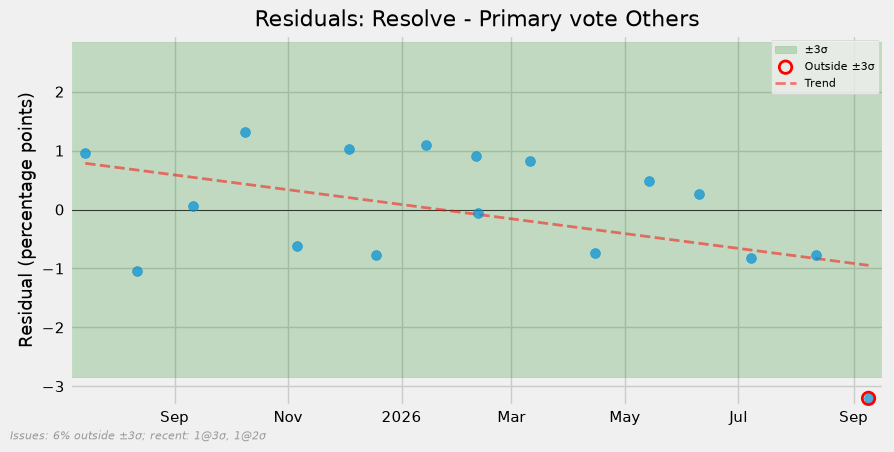

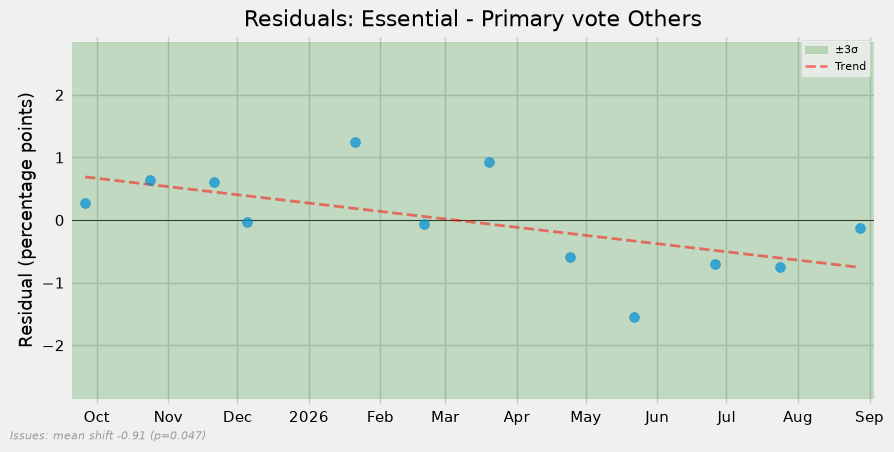

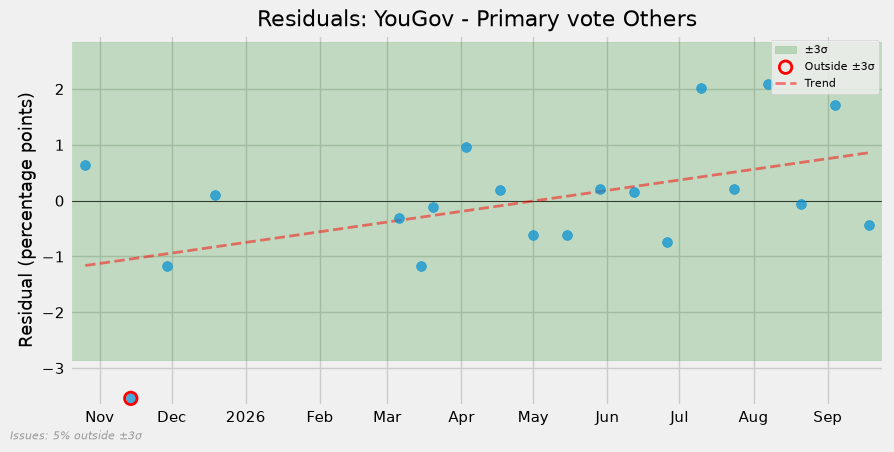

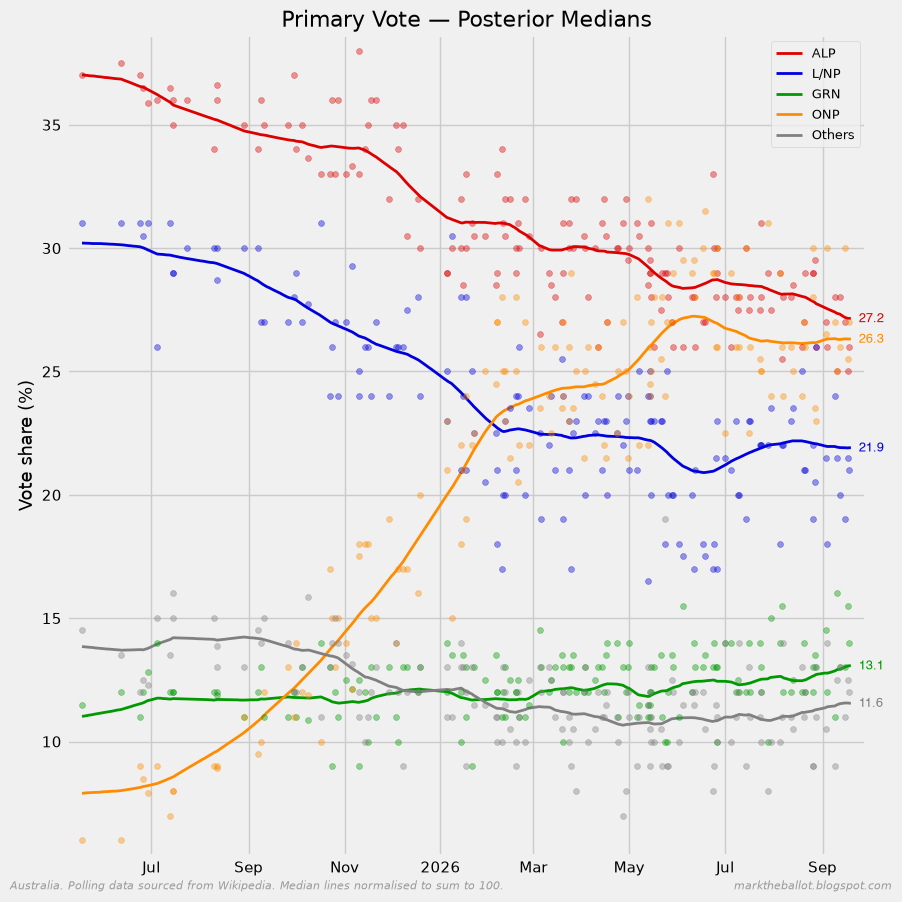

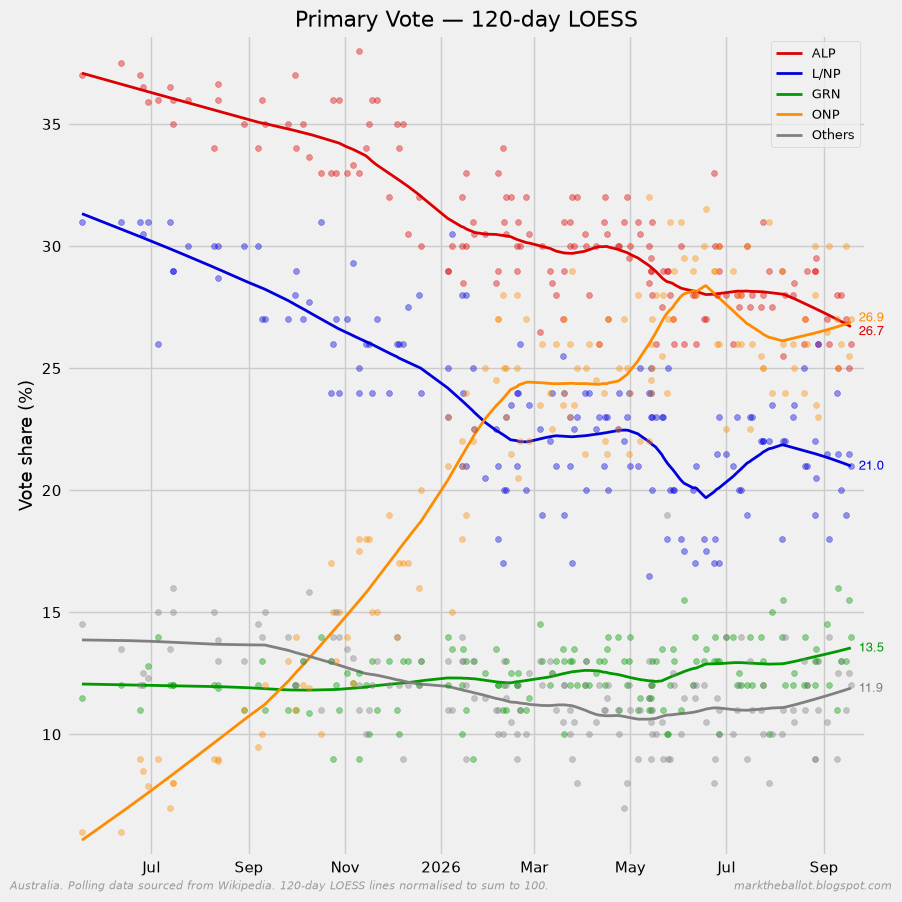

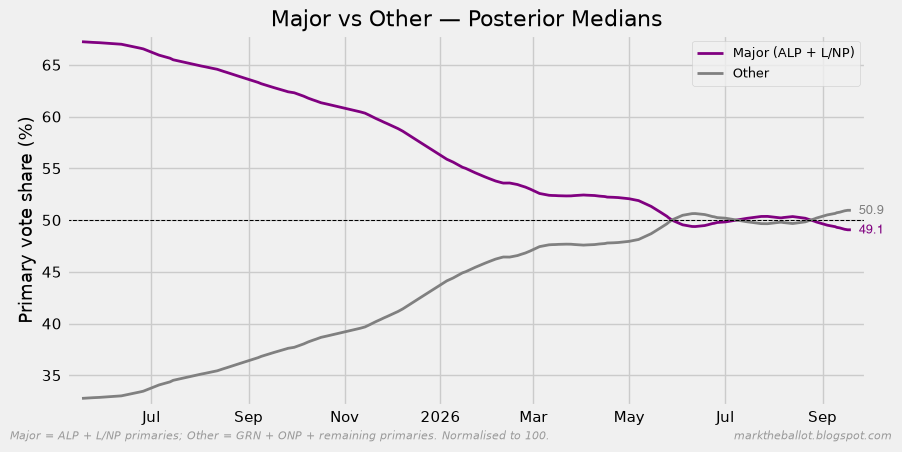

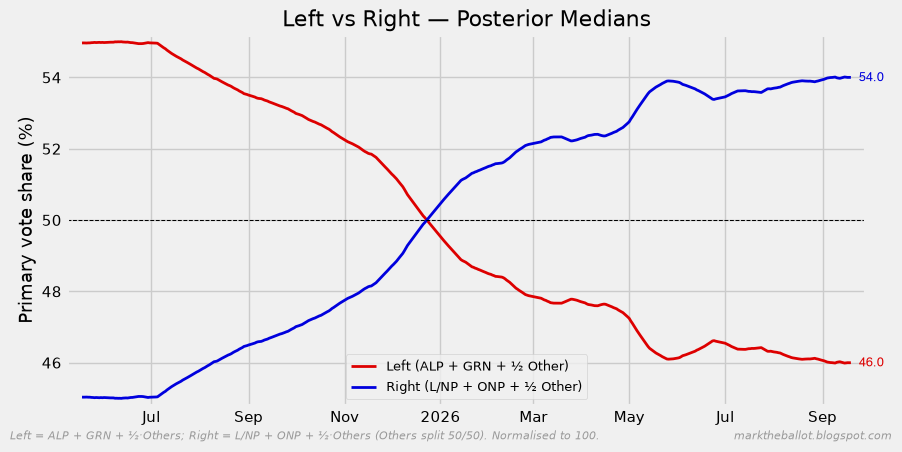

/Users/bryanpalmer/Election-2028/notebooks/pymc/bayes_tools.py:585: FutureWarning: `nuts_sampler_kwargs` is deprecated. Pass NUTS keyword arguments via the `nuts={...}` argument to `pm.sample`.
  idata = pm.sample(
NUTS[numpyro]: [voting_intention, raw_he, sigma_obs, nu]



Processing: 2PP vote ALP
Polls: 127
Pollsters: ['Roy Morgan', 'YouGov', 'RedBridge/Accent', 'Essential', 'Resolve', 'Newspoll', 'Spectre Strategy', 'Fox & Hedgehog', 'Freshwater', 'DemosAU', 'Wolf & Smith']
Constraint: zero_median
sigma_obs HalfNormal prior: {'sigma': 5}
nu Gamma prior: {'alpha': 2, 'beta': 0.1}


  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

Maximum R-hat: 1.0000
Minimum ESS: 2100
Maximum MCSE/sd ratio: 0.021
Divergent transitions: 0/20000 (0.0000%)
Tree depth at max (12): 2.00% (comparing to observed max)
Minimum BFMI: 0.96
Completed: 2PP vote ALP


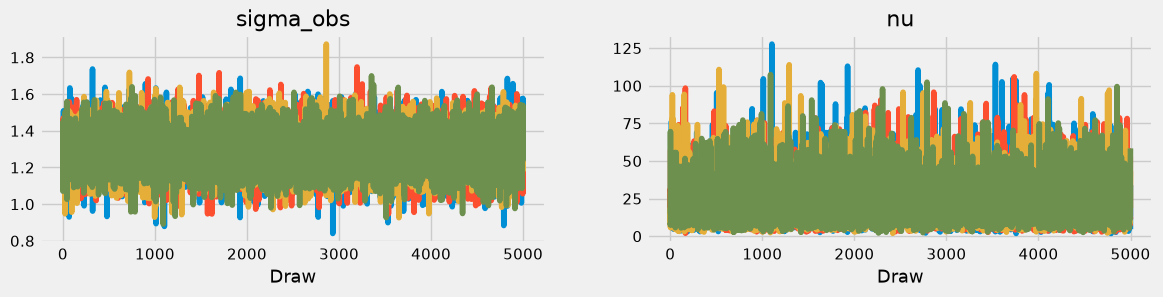

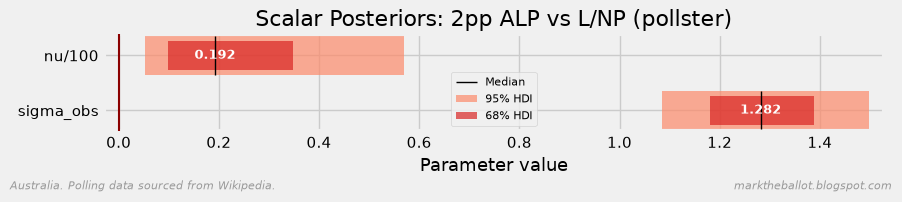

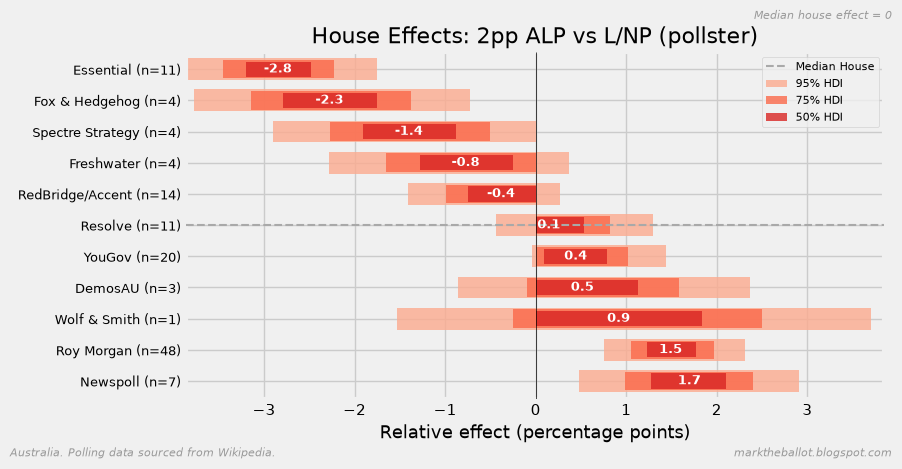

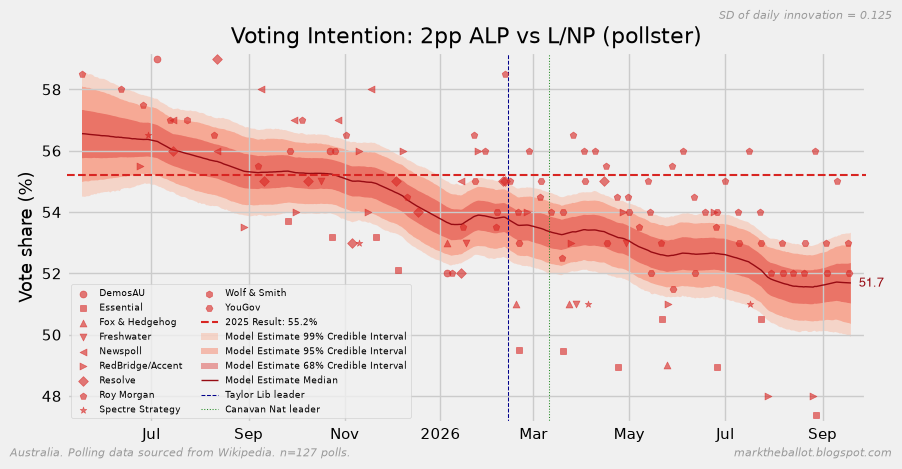

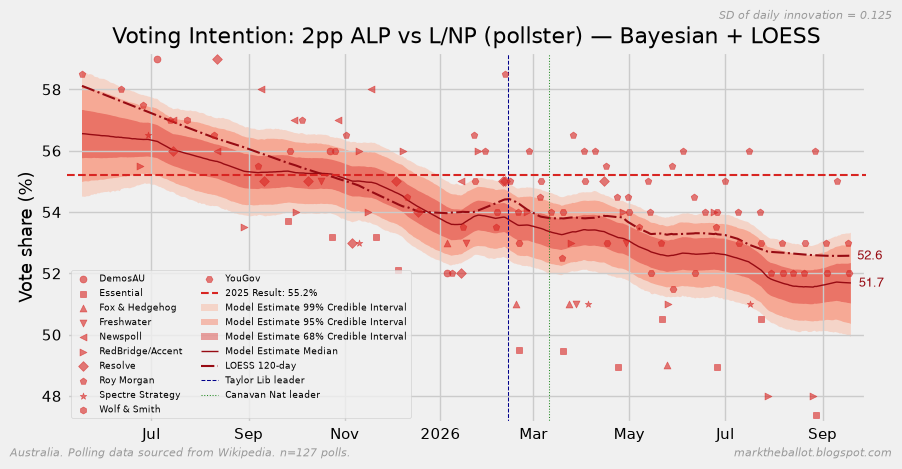


=== Residual Diagnostics by Pollster ===
Model sigma_obs: 1.28
Minimum polls required: 5

Roy Morgan (n=48)
  Outside ±3σ: 0/48 (0.0%)
  Heteroskedasticity p-value: 0.545 (homoskedastic)
  Recent outliers: 0@3σ, 1@2σ (of 5)
  Mean shift: +0.47 (t-test p=0.203)

RedBridge/Accent (n=14) ⚠️ SUSPECT
  Outside ±3σ: 0/14 (0.0%)
  Heteroskedasticity p-value: 0.024 (variance increasing)
  Recent outliers: 0@3σ, 2@2σ (of 5)
  Mean shift: -0.90 (t-test p=0.381)

Newspoll (n=7)
  Outside ±3σ: 0/7 (0.0%)
  Heteroskedasticity p-value: 0.567 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +0.65 (t-test p=0.468)

Resolve (n=11)
  Outside ±3σ: 0/11 (0.0%)
  Heteroskedasticity p-value: 0.501 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +0.28 (t-test p=0.787)

Essential (n=11)
  Outside ±3σ: 0/11 (0.0%)
  Heteroskedasticity p-value: 0.306 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.87 (t-test p=0.211)

YouGov (n=20)
  Outside ±3σ: 0/20 

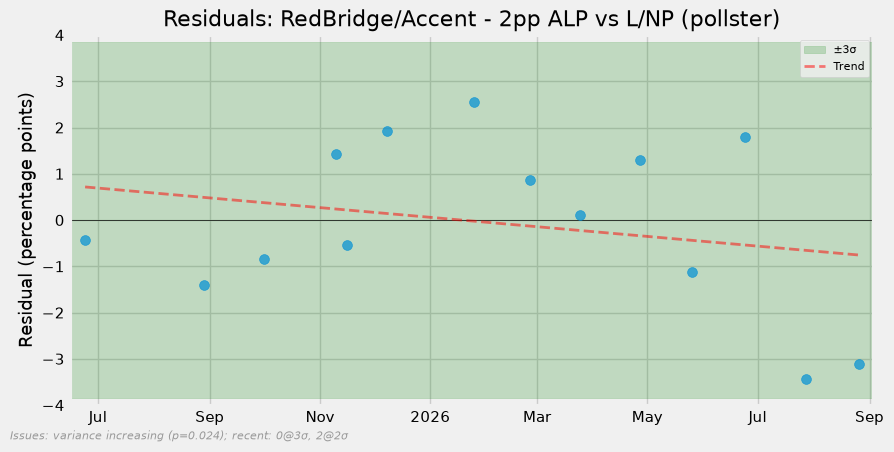

/Users/bryanpalmer/Election-2028/notebooks/pymc/bayes_tools.py:585: FutureWarning: `nuts_sampler_kwargs` is deprecated. Pass NUTS keyword arguments via the `nuts={...}` argument to `pm.sample`.
  idata = pm.sample(
NUTS[numpyro]: [voting_intention, raw_he, sigma_obs, nu]



Processing: 2PP vote ALP
Polls: 54
Pollsters: ['Roy Morgan', 'YouGov', 'RedBridge/Accent', 'Fox & Hedgehog', 'Spectre Strategy', 'Freshwater', 'DemosAU']
Constraint: zero_median
sigma_obs HalfNormal prior: {'sigma': 5}
nu Gamma prior: {'alpha': 2, 'beta': 0.1}


  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

Maximum R-hat: 1.0000
Minimum ESS: 3400
Maximum MCSE/sd ratio: 0.017
Divergent transitions: 0/20000 (0.0000%)
Tree depth at max (11): 2.39% (comparing to observed max)
Minimum BFMI: 0.98
Completed: 2PP vote ALP


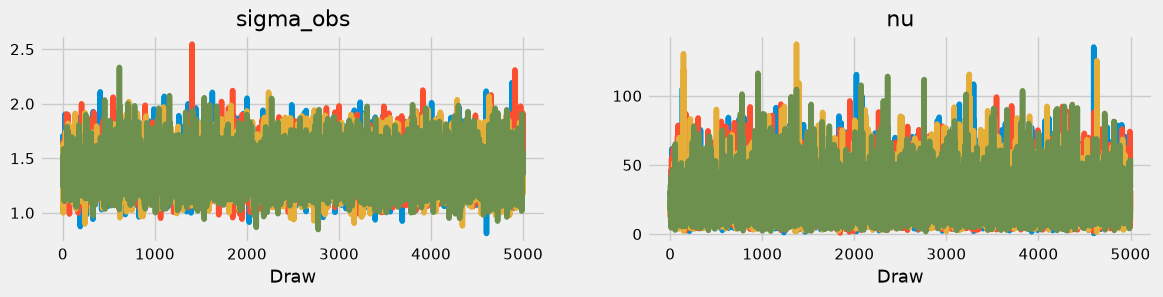

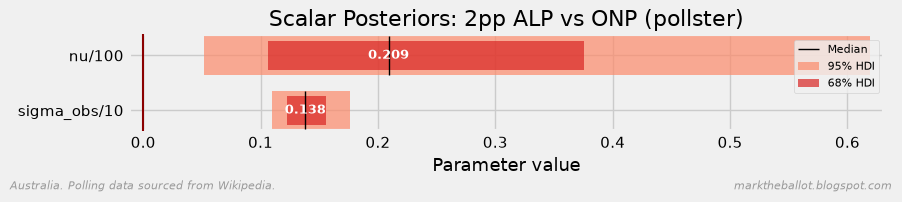

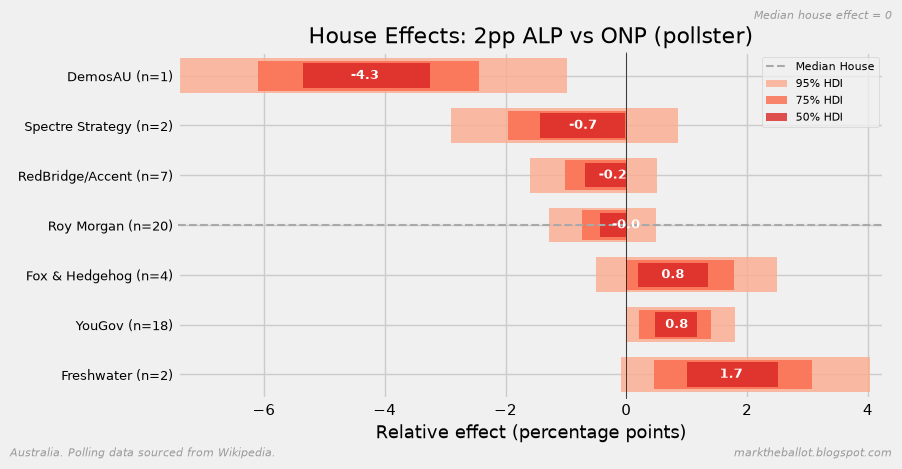

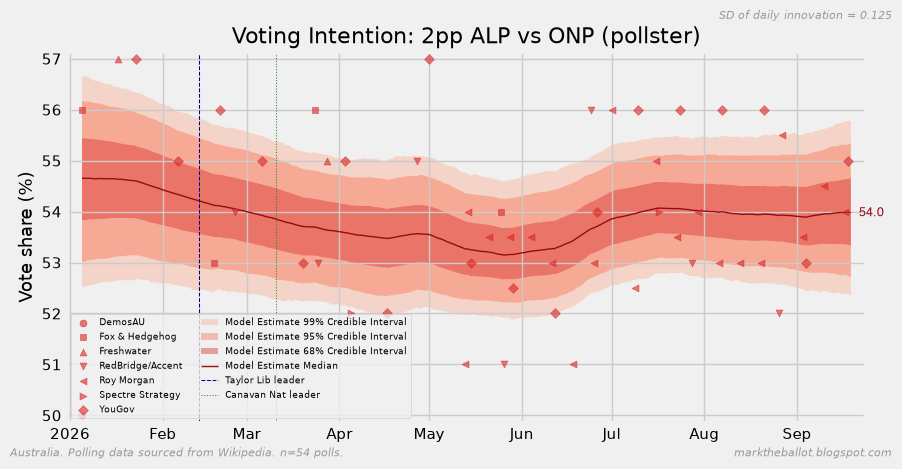

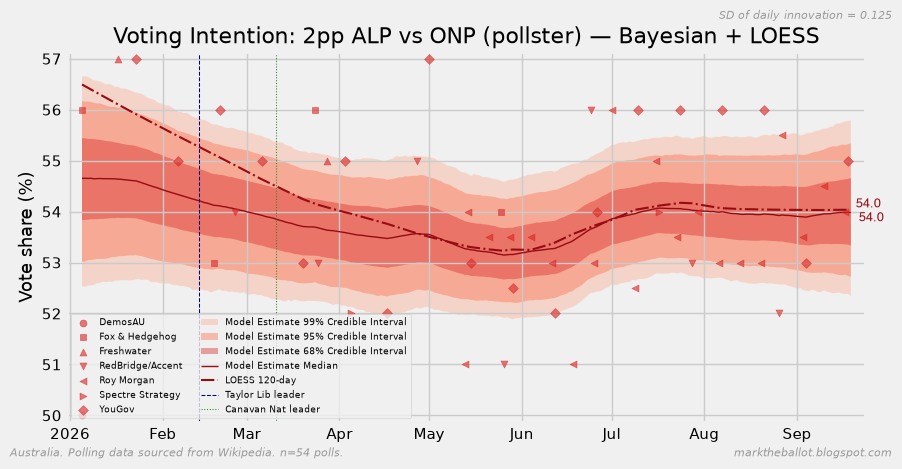

/Users/bryanpalmer/Election-2028/notebooks/pymc/bayes_tools.py:585: FutureWarning: `nuts_sampler_kwargs` is deprecated. Pass NUTS keyword arguments via the `nuts={...}` argument to `pm.sample`.
  idata = pm.sample(
NUTS[numpyro]: [voting_intention, raw_he, sigma_obs, nu]



=== Residual Diagnostics by Pollster ===
Model sigma_obs: 1.39
Minimum polls required: 5

YouGov (n=18)
  Outside ±3σ: 0/18 (0.0%)
  Heteroskedasticity p-value: 0.885 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.23 (t-test p=0.741)

RedBridge/Accent (n=7)
  Outside ±3σ: 0/7 (0.0%)
  Heteroskedasticity p-value: 0.442 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.94 (t-test p=0.477)

Roy Morgan (n=20)
  Outside ±3σ: 0/20 (0.0%)
  Heteroskedasticity p-value: 0.341 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +0.25 (t-test p=0.637)

✓ No pollsters flagged for methodology concerns.

Processing: 2PP synth-2025 ALP
Polls: 156
Pollsters: ['Roy Morgan', 'YouGov', 'Newspoll', 'Resolve', 'RedBridge/Accent', 'DemosAU', 'Essential', 'Freshwater', 'Spectre Strategy', 'Fox & Hedgehog', 'Agenda C Synesis', 'Wolf & Smith']
Constraint: zero_median
sigma_obs HalfNormal prior: {'sigma': 5}
nu Gamma prior: {'alpha': 2, 'beta': 0.1}


  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

Maximum R-hat: 1.0000
Minimum ESS: 5000
Maximum MCSE/sd ratio: 0.015
Divergent transitions: 0/20000 (0.0000%)
Tree depth at max (12): 0.16% (comparing to observed max)
Minimum BFMI: 1.00
Completed: 2PP synth-2025 ALP


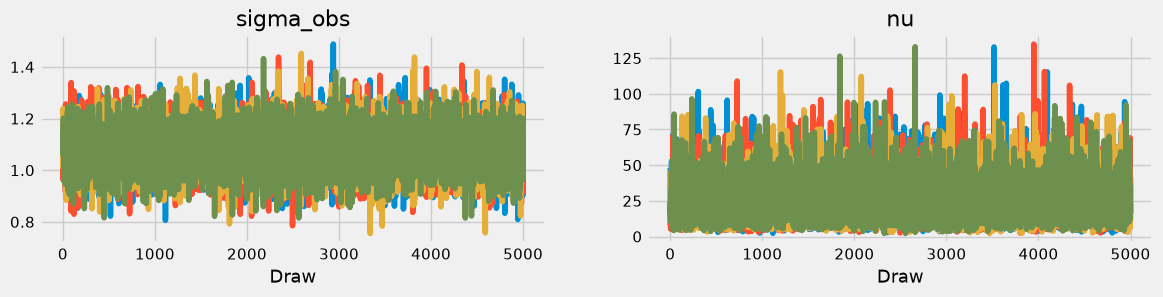

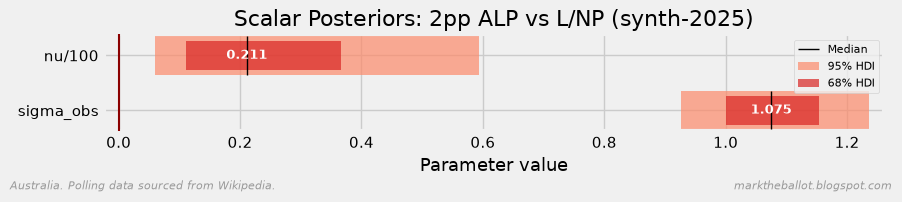

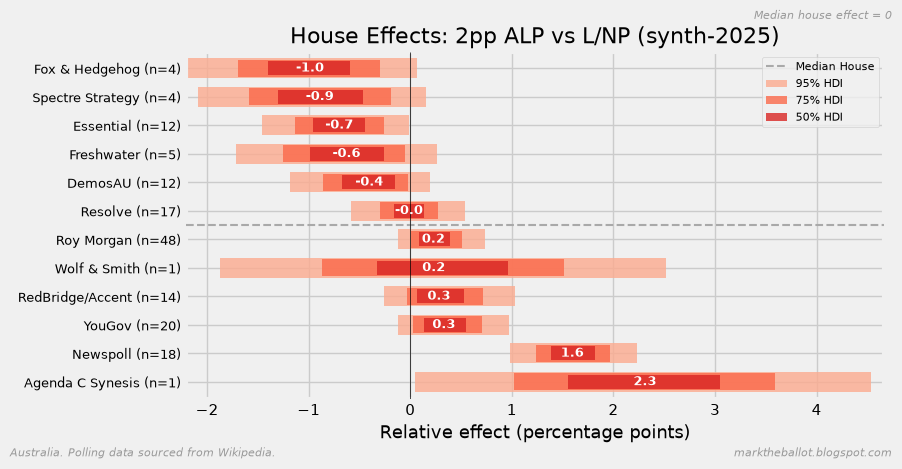

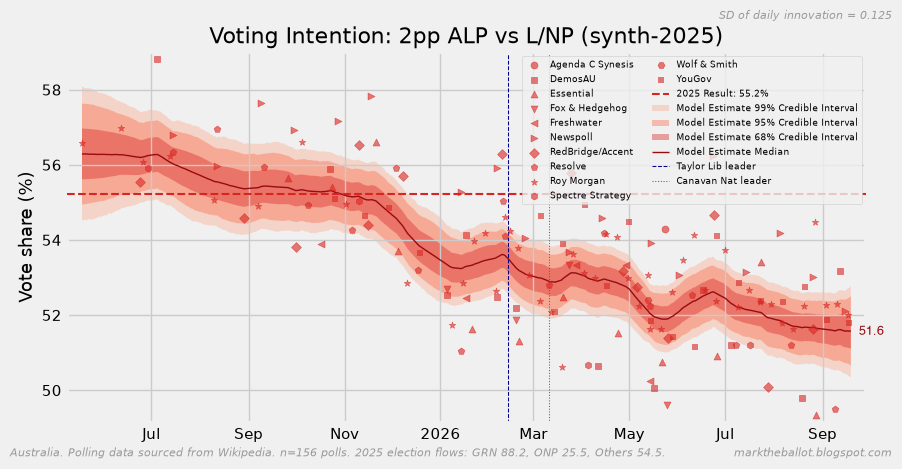

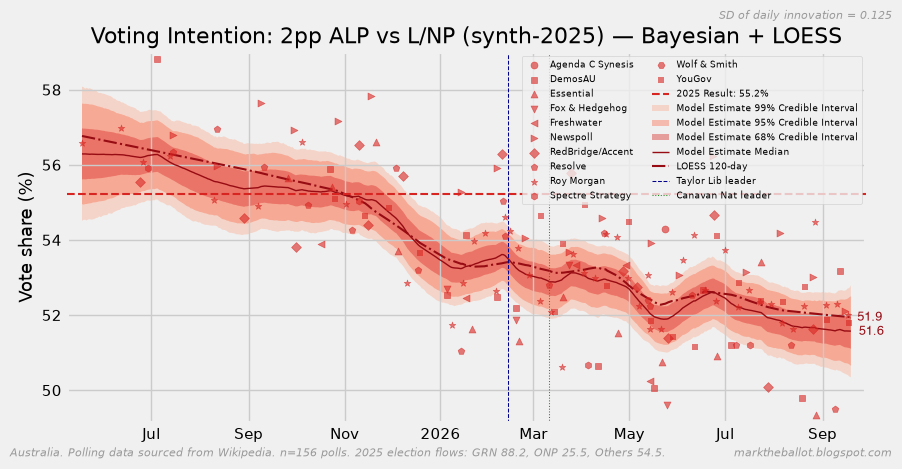


=== Residual Diagnostics by Pollster ===
Model sigma_obs: 1.08
Minimum polls required: 5

Roy Morgan (n=48) ⚠️ SUSPECT
  Outside ±3σ: 0/48 (0.0%)
  Heteroskedasticity p-value: 0.707 (homoskedastic)
  Recent outliers: 0@3σ, 1@2σ (of 5)
  Mean shift: +0.68 (t-test p=0.005)

RedBridge/Accent (n=14)
  Outside ±3σ: 0/14 (0.0%)
  Heteroskedasticity p-value: 0.738 (homoskedastic)
  Recent outliers: 0@3σ, 1@2σ (of 5)
  Mean shift: +0.17 (t-test p=0.842)

DemosAU (n=12)
  Outside ±3σ: 0/12 (0.0%)
  Heteroskedasticity p-value: 0.245 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -1.07 (t-test p=0.235)

Resolve (n=17)
  Outside ±3σ: 0/17 (0.0%)
  Heteroskedasticity p-value: 0.534 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: +0.05 (t-test p=0.932)

Newspoll (n=18)
  Outside ±3σ: 0/18 (0.0%)
  Heteroskedasticity p-value: 0.650 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.13 (t-test p=0.761)

Essential (n=12)
  Outside ±3σ: 0/12 (0.

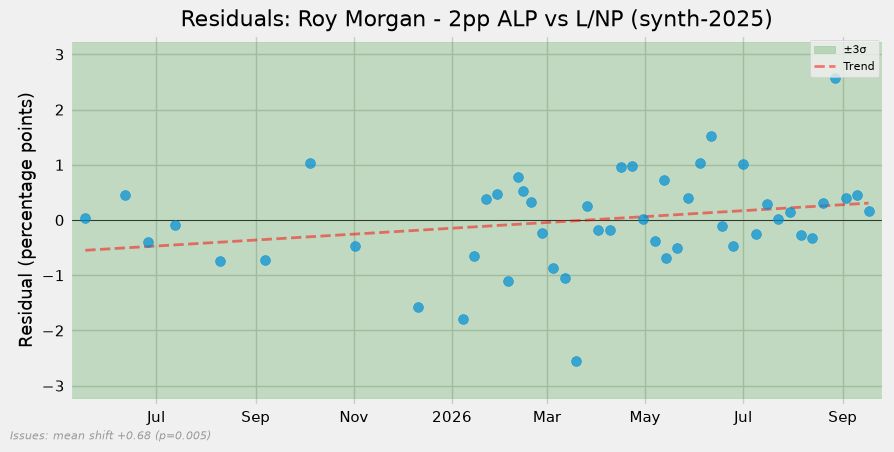

/Users/bryanpalmer/Election-2028/notebooks/pymc/bayes_tools.py:585: FutureWarning: `nuts_sampler_kwargs` is deprecated. Pass NUTS keyword arguments via the `nuts={...}` argument to `pm.sample`.
  idata = pm.sample(
NUTS[numpyro]: [voting_intention, raw_he, sigma_obs, nu]



Processing: 2PP synth-sa26 ALP
Polls: 156
Pollsters: ['Roy Morgan', 'YouGov', 'Newspoll', 'Resolve', 'RedBridge/Accent', 'DemosAU', 'Essential', 'Freshwater', 'Spectre Strategy', 'Fox & Hedgehog', 'Agenda C Synesis', 'Wolf & Smith']
Constraint: zero_median
sigma_obs HalfNormal prior: {'sigma': 5}
nu Gamma prior: {'alpha': 2, 'beta': 0.1}


  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

Maximum R-hat: 1.0000
Minimum ESS: 4700
Maximum MCSE/sd ratio: 0.015
Divergent transitions: 0/20000 (0.0000%)
Tree depth at max (12): 0.01% (comparing to observed max)
Minimum BFMI: 0.96
Completed: 2PP synth-sa26 ALP


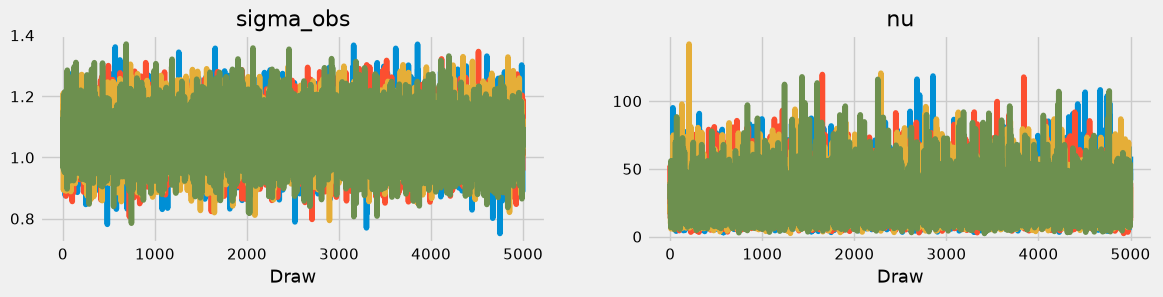

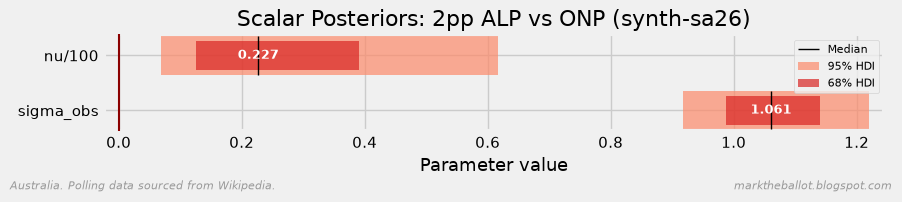

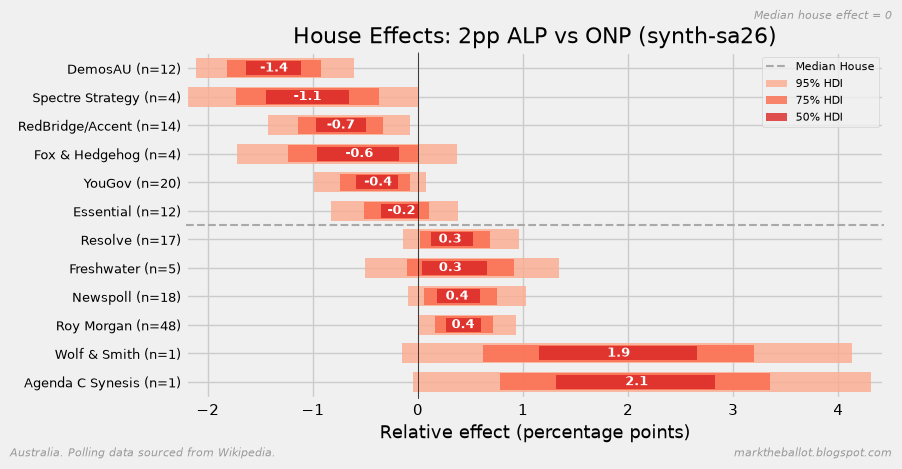

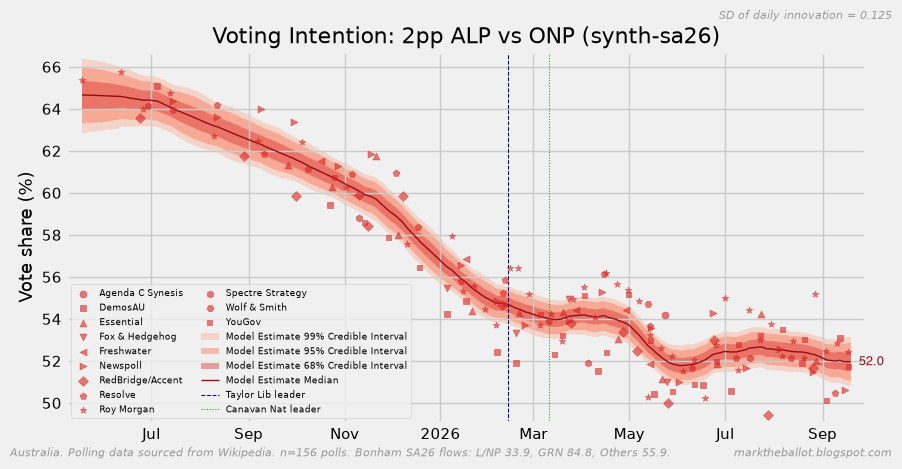

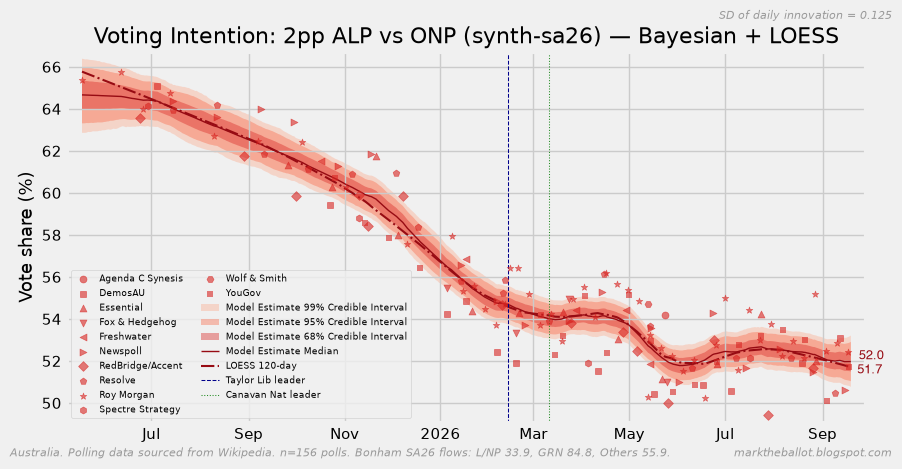


=== Residual Diagnostics by Pollster ===
Model sigma_obs: 1.06
Minimum polls required: 5

Roy Morgan (n=48)
  Outside ±3σ: 0/48 (0.0%)
  Heteroskedasticity p-value: 0.211 (homoskedastic)
  Recent outliers: 0@3σ, 1@2σ (of 5)
  Mean shift: +0.28 (t-test p=0.369)

RedBridge/Accent (n=14)
  Outside ±3σ: 0/14 (0.0%)
  Heteroskedasticity p-value: 0.294 (homoskedastic)
  Recent outliers: 0@3σ, 1@2σ (of 5)
  Mean shift: -0.41 (t-test p=0.510)

DemosAU (n=12)
  Outside ±3σ: 0/12 (0.0%)
  Heteroskedasticity p-value: 0.965 (homoskedastic)
  Recent outliers: 0@3σ, 1@2σ (of 5)
  Mean shift: +0.27 (t-test p=0.723)

Resolve (n=17)
  Outside ±3σ: 0/17 (0.0%)
  Heteroskedasticity p-value: 0.220 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.22 (t-test p=0.626)

Newspoll (n=18)
  Outside ±3σ: 0/18 (0.0%)
  Heteroskedasticity p-value: 0.209 (homoskedastic)
  Recent outliers: 0@3σ, 0@2σ (of 5)
  Mean shift: -0.79 (t-test p=0.114)

Essential (n=12)
  Outside ±3σ: 0/12 (0.0%)
  Heter

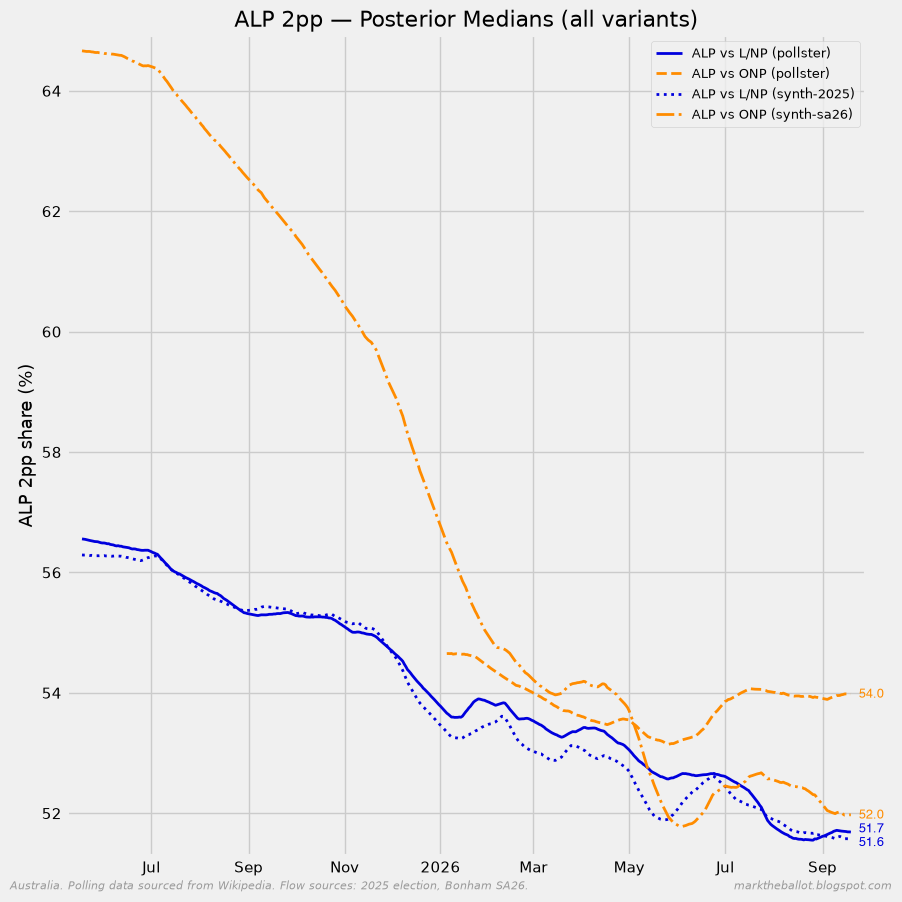

In [16]:
def run_all(df: pd.DataFrame) -> None:
    """Fit GRWs for every party in PRIMARIES and every 2pp variant in TPP_FITS,
    producing the standard chart set + diagnostics for each. Primaries run
    first, then 2pp. Emits the combined 9x9 charts: primary medians, primary
    90-day LOESS, and blocs, then 2pp medians."""
    # --- Primaries first ---
    primary_medians: dict[str, pd.Series] = {}
    primary_loess: dict[str, pd.Series] = {}
    primary_polls: dict[str, pd.DataFrame] = {}
    for party in PRIMARIES:
        column = primary_column(party)
        poll_df = get_primary(df, party)
        result = grw_plot(
            df=poll_df,
            column=column,
            color=get_palette(party),
            title=f"Primary vote {party}",
            election_result=get_election_result(column),
        )
        primary_medians[party] = result["median"]
        primary_loess[party] = result["loess"]
        poll_df = poll_df.copy()
        poll_df.index = pd.PeriodIndex(poll_df[MIDDLE_DATE], freq="D")
        primary_polls[party] = poll_df

    plot_primary_medians_combined(primary_medians, primary_polls)
    plot_primary_loess_combined(primary_loess, primary_polls, day_span=120)
    plot_blocs_combined(primary_medians)

    # --- 2pp variants ---
    tpp_medians: dict[str, pd.Series] = {}
    for cfg in TPP_FITS:
        party, counter, variant = cfg["party"], cfg["counter"], cfg["variant"]
        alp_col, _ = tpp_columns(variant, party, counter)
        result = grw_plot(
            df=get_2pp(df, party, counter, variant=variant),
            column=alp_col,
            color=get_palette(party),
            title=f"2pp {party} vs {counter} ({variant})",
            election_result=tpp_election_result(party, counter),
            footer_note=SYNTHETIC_FOOTERS.get(variant, ""),
        )
        label = f"{party} vs {counter} ({variant})"
        tpp_medians[label] = result["median"]

    plot_2pp_medians_combined(tpp_medians)


run_all(df)

## Finished

In [17]:
%load_ext watermark
%watermark -t -d -u --python --machine --conda --iversions --watermark

Last updated: 2026-09-23 13:41:48

Python implementation: CPython
Python version       : 3.14.2
IPython version      : 9.17.1

conda environment: n/a

Compiler    : Clang 21.1.4 
OS          : Darwin
Release     : 27.0.0
Machine     : arm64
Processor   : arm
CPU cores   : 14
Architecture: 64bit

matplotlib: 3.11.2
mgplot    : 0.2.33
numpy     : 2.5.3
pandas    : 3.0.6

Watermark: 2.6.0

